In [1]:
import os
import sys
import time
import datetime
import pickle
import numpy as np
import pandas as pd

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

from pytensor.graph.op import Op
from pytensor.link.jax.dispatch import jax_funcify
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

from efficient_fpt_jax.multi_stage import get_addm_fptd_jax_fast, pad_sacc_array_safely

/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Datasets

In [2]:
monk_data_1 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_1.csv")
monk_data_2 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_2.csv")
monk_data_3 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_3.csv")

print(f"Monkey 1: {len(monk_data_1)} trials")
print(f"Monkey 2: {len(monk_data_2)} trials")
print(f"Monkey 3: {len(monk_data_3)} trials")

Monkey 1: 587 trials
Monkey 2: 607 trials
Monkey 3: 606 trials


In [5]:
monk_data_1.sort_values(by="trialNum", ascending=True)
monk_data_1 = monk_data_1[monk_data_1["liftRT"] < 2]
monk_data_1

,trialNum,lVal,rVal,firstVal,secondVal,chosenVal,leftChosen,firstChosen,liftRT,reachRT,firstIsLeft,firstIsRight,secondIsLeft,secondIsRight,firstFixLat,secondFixLat,thirdFixLat,firstFixDur,secondFixDur,thirdFixDur
0,6,3,1,1,3,3,1,0,0.827066,0.154888,0,1,1,0,0.162,0.510,NaN,0.304,0.468,NaN
1,11,1,2,1,2,1,1,1,0.847049,0.141345,1,0,0,1,0.164,0.372,0.616,0.160,0.200,0.564
2,18,5,1,1,5,5,1,0,0.897351,0.152484,0,1,1,0,0.166,0.414,NaN,0.184,1.004,NaN
3,61,1,1,1,1,1,1,0,0.877376,0.172368,0,1,1,0,0.163,0.415,NaN,0.204,0.836,NaN
4,62,5,1,1,5,5,1,0,0.937264,0.162975,0,1,1,0,0.178,0.430,NaN,0.212,0.956,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,481,5,5,5,5,5,1,1,0.739332,0.156969,1,0,0,1,0.213,0.441,0.617,0.180,0.136,0.520
583,494,2,5,5,2,5,0,1,0.807278,0.169131,0,1,1,0,0.222,0.526,0.670,0.260,0.100,0.580
584,503,5,5,5,5,5,1,1,0.757297,0.148997,1,0,0,1,0.184,0.452,0.632,0.216,0.128,0.488
585,518,5,3,5,3,5,1,1,0.687202,0.162062,1,0,0,1,0.160,0.404,0.540,0.196,0.092,0.612


In [11]:
max(monk_data_1['lVal'] - monk_data_1['rVal'])

4

## Global Configuration

In [6]:
sigma    = 1.0   # Fixed noise (unidentifiable with other params)
max_d    = 4    # Max fixation stages (padded saccade dimension)

TRUNC_NUM   = 6    # Series truncation (optimal for JAX/XLA)
N_DRAWS     = 500
N_TUNE      = 500
# N_CHAINS    = 4
N_CHAINS = 2
RANDOM_SEED = 42

## Helper Functions

In [24]:
def preprocess_monkey_data(df, max_d):
    """
    Transform a raw monkey-behaviour DataFrame into model-ready numpy arrays.

    Parameters
    ----------
    df : pd.DataFrame
        Raw behavioural table with columns: trialNum, lVal, rVal,
        firstFixLat, secondFixLat, thirdFixLat, firstIsLeft,
        liftRT, leftChosen.
    max_d : int
        Maximum number of fixation stages (width of padded saccade array).

    Returns
    -------
    dict with keys:
        r1, r2          : left / right value per trial
        rt              : reaction time relative to first fixation onset
        choice          : +1 (left chosen) / -1 (right chosen)
        flag_data       : 0 if first fixation is left, 1 if right
        sacc            : (n_trials, max_d) padded saccade-onset array
        length_data     : number of fixations per trial (2 or 3)
    """
    DATA_TYPE = np.float64
    df = df.sort_values(by='trialNum', ascending=True)
    df = df[df["liftRT"] < 2]  # Filter out trials with RT >= 2s (outliers)

    r1 = df['lVal'].to_numpy(dtype=DATA_TYPE)
    r2 = df['rVal'].to_numpy(dtype=DATA_TYPE)

    third_present = df['thirdFixLat'].notna().to_numpy()
    length_data = np.where(third_present, 3, 2).astype(np.int32)

    t0 = df["firstFixLat"].to_numpy(dtype=DATA_TYPE)
    t1 = df["secondFixLat"].to_numpy(dtype=DATA_TYPE)
    t2 = df["thirdFixLat"].fillna(0).to_numpy(dtype=DATA_TYPE)

    sacc = np.zeros((len(df), max_d), dtype=DATA_TYPE)
    sacc[:, 0] = 0.0
    sacc[:, 1] = t1 - t0
    sacc[third_present, 2] = t2[third_present] - t0[third_present]

    first_is_left = df['firstIsLeft'].to_numpy().astype(int)
    flag_data = np.where(first_is_left == 1, 0, 1).astype(np.int32)

    rt_raw = df["liftRT"].to_numpy(dtype=DATA_TYPE)
    rt = rt_raw - t0 - 0.1 

    left_chosen = df["leftChosen"].to_numpy().astype(int)
    choice = np.where(left_chosen == 1, 1.0, -1.0).astype(np.int32)

    return dict(r1=r1, r2=r2, rt=rt, choice=choice,
                flag_data=flag_data, sacc=sacc, length_data=length_data)


def preprocess_monkey_data_fixdur(df, max_d):
    """
    Alternative preprocessing where model time corresponds to time spent fixating
    (inter-fixation lag/saccade gaps are removed from both RT and saccade onsets).

    RT = sum of fixation durations, with the LAST fixation's duration computed as
        liftRT - 0.1 - firstFixLat - sum(inter-fixation lags)
    where each inter-fixation lag is (nextFixLat - prevFixLat - prevFixDur).
    Earlier fixations use their reported durations (firstFixDur, secondFixDur).

    Saccade onset array is cumulative fixation duration:
        sacc[:, 0] = 0
        sacc[:, 1] = firstFixDur
        sacc[:, 2] = firstFixDur + secondFixDur   (only for 3-fixation trials)

    Parameters and returns mirror `preprocess_monkey_data`.
    """
    DATA_TYPE = np.float64
    df = df.sort_values(by='trialNum', ascending=True)
    df = df[df["liftRT"] < 2]  # Filter out trials with RT >= 2s (outliers)


    r1 = df['lVal'].to_numpy(dtype=DATA_TYPE)
    r2 = df['rVal'].to_numpy(dtype=DATA_TYPE)

    third_present = df['thirdFixLat'].notna().to_numpy()
    length_data = np.where(third_present, 3, 2).astype(np.int32)

    firstFixLat  = df["firstFixLat"].to_numpy(dtype=DATA_TYPE)
    secondFixLat = df["secondFixLat"].to_numpy(dtype=DATA_TYPE)
    thirdFixLat  = df["thirdFixLat"].fillna(0).to_numpy(dtype=DATA_TYPE)

    firstFixDur  = df["firstFixDur"].to_numpy(dtype=DATA_TYPE)
    secondFixDur = df["secondFixDur"].fillna(0).to_numpy(dtype=DATA_TYPE)

    # Inter-fixation lag (gap between end of fix_i and onset of fix_{i+1})
    lag1 = secondFixLat - firstFixLat  - firstFixDur                        # always present
    lag2 = np.where(third_present,
                    thirdFixLat - secondFixLat - secondFixDur,
                    0.0)                                                    # only on 3-fix trials

    liftRT = df["liftRT"].to_numpy(dtype=DATA_TYPE)
    total_lag = lag1 + lag2
    final_dur = liftRT - 0.1 - firstFixLat - total_lag

    rt = np.where(third_present,
                  firstFixDur + secondFixDur + final_dur,
                  firstFixDur + final_dur)
    mask = rt < 2.0
    rt = rt[mask]
    sacc = np.zeros((len(df), max_d), dtype=DATA_TYPE)
    sacc[:, 0] = 0.0
    sacc[:, 1] = firstFixDur
    sacc[third_present, 2] = (firstFixDur[third_present]
                              + secondFixDur[third_present])

    first_is_left = df['firstIsLeft'].to_numpy().astype(int)
    flag_data = np.where(first_is_left == 1, 0, 1).astype(np.int32)

    left_chosen = df["leftChosen"].to_numpy().astype(int)
    choice = np.where(left_chosen == 1, 1.0, -1.0).astype(np.int32)
    choice = choice[mask]
    r1 = r1[mask]
    r2 = r2[mask]
    flag_data = flag_data[mask]
    sacc = sacc[mask]
    length_data = length_data[mask]
    return dict(r1=r1, r2=r2, rt=rt, choice=choice,
                flag_data=flag_data, sacc=sacc, length_data=length_data)


In [8]:
def make_jax_arrays(data, max_d):
    """
    Convert preprocessed numpy dict to JAX arrays and pre-compute
    safe saccade arrays (prevents NaN gradients at boundary).

    Parameters
    ----------
    data  : dict returned by preprocess_monkey_data
    max_d : int  (must match the value used during preprocessing)

    Returns
    -------
    dict of JAX arrays: rt, choice, d, r1, r2, flag, sacc_safe
    """
    jax_sacc = jnp.array(data['sacc'])
    jax_d    = jnp.array(data['length_data'])
    jax_sacc_safe = vmap(
        lambda s, d: pad_sacc_array_safely(s, d, max_d)
    )(jax_sacc, jax_d)

    return dict(
        rt       = jnp.array(data['rt']),
        choice   = jnp.array(data['choice']),
        d        = jax_d,
        r1       = jnp.array(data['r1']),
        r2       = jnp.array(data['r2']),
        flag     = jnp.array(data['flag_data']),
        sacc_safe= jax_sacc_safe,
    )

## Dataset-Agnostic JAX Likelihood Helpers

In [9]:
def compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d):
    """
    Compute the alternating drift array for a single trial.

    flag=0 (first fixation left):  [mu1, mu2, mu1, mu2, ...]
    flag=1 (first fixation right): [mu2, mu1, mu2, mu1, ...]
    """
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    indices = jnp.arange(max_d)
    return jnp.where((indices % 2) == flag, mu1, mu2)


def jax_loglik_single(rt, choice, d, r1, r2, flag, sacc_safe,
                      eta, kappa, a, b, x0, sigma, max_d, trunc_num):
    """Log-likelihood for a single trial."""
    mu_array = compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d)
    fptd = get_addm_fptd_jax_fast(
        rt, d, mu_array, sacc_safe, sigma, a, b, x0, choice,
        order=30, trunc_num=trunc_num, safe_sacc=sacc_safe
    )
    return jnp.log(jnp.maximum(fptd, 1e-30))

In [10]:
def make_jax_likelihood(jax_data, sigma, max_d, trunc_num):
    """
    Build and JIT-compile JAX log-likelihood and gradient functions
    closed over a specific dataset.

    Parameters
    ----------
    jax_data  : dict returned by make_jax_arrays
    sigma     : float  noise parameter (fixed)
    max_d     : int    saccade array width
    trunc_num : int    series truncation number

    Returns
    -------
    loglik_jit   : jit-compiled total log-likelihood (eta, kappa, a, b, x0) -> scalar
    grad_loglik  : jit-compiled gradient tuple     (eta, kappa, a, b, x0) -> 5-tuple
    """
    def loglik_batch(eta, kappa, a, b, x0):
        per_trial = vmap(
            lambda rt, choice, d, r1, r2, flag, sacc_safe: jax_loglik_single(
                rt, choice, d, r1, r2, flag, sacc_safe,
                eta, kappa, a, b, x0, sigma, max_d, trunc_num
            )
        )
        logliks = per_trial(
            jax_data['rt'], jax_data['choice'], jax_data['d'],
            jax_data['r1'], jax_data['r2'], jax_data['flag'], jax_data['sacc_safe']
        )
        return jnp.sum(logliks)

    loglik_jit  = jit(loglik_batch)
    grad_loglik = jit(grad(loglik_batch, argnums=(0, 1, 2, 3, 4)))
    return loglik_jit, grad_loglik

## PyTensor Custom Ops (dataset-agnostic)

In [11]:
class LogLikeJAX(Op):
    """PyTensor Op wrapping a JAX likelihood with analytic gradients."""
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, loglik_fn, grad_fn):
        self.loglik_fn = loglik_fn
        self.grad_fn   = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        outputs[0][0] = np.array(float(self.loglik_fn(eta, kappa, a, b, x0)),
                                 dtype="float64")

    def grad(self, inputs, output_grads):
        (theta,)  = inputs
        (g_out,)  = output_grads
        grads = LogLikeJAXGrad(self.grad_fn)(theta)
        return [g_out * grads]


class LogLikeJAXGrad(Op):
    """Gradient Op for LogLikeJAX."""
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, grad_fn):
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        grads = self.grad_fn(eta, kappa, a, b, x0)
        outputs[0][0] = np.array([float(g) for g in grads], dtype="float64")


@jax_funcify.register(LogLikeJAX)
def jax_funcify_LogLikeJAX(op, **kwargs):
    loglik_fn = op.loglik_fn
    def loglik_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return loglik_fn(eta, kappa, a, b, x0)
    return loglik_jax


@jax_funcify.register(LogLikeJAXGrad)
def jax_funcify_LogLikeJAXGrad(op, **kwargs):
    grad_fn = op.grad_fn
    def grad_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return jnp.stack(grad_fn(eta, kappa, a, b, x0))
    return grad_jax

In [12]:
def make_pymc_model(loglike_op, M):
    """
    Construct a PyMC model with the custom JAX likelihood.

    Parameters
    ----------
    loglike_op : LogLikeJAX instance bound to a specific dataset
    M          : float  max observed RT (used to bound the collapse rate b)

    Returns
    -------
    pm.Model
    """
    with pm.Model() as model:
        eta     = pm.Beta("eta",   alpha=2.0, beta=2.0)
        kappa   = pm.Gamma("kappa", alpha=2.0, beta=4.0)
        a_param = pm.Gamma("a",     alpha=4.0, beta=2.0)

        b_raw   = pm.Beta("b_raw", alpha=2.0, beta=2.0)
        b_param = pm.Deterministic("b", b_raw * a_param / M * 0.95)
        # b_param = 0.0

        x0_raw  = pm.Beta("x0_raw", alpha=2.0, beta=2.0)
        x0_param= pm.Deterministic("x0", -a_param + 2.0 * a_param * x0_raw)

        theta = pt.stack([eta, kappa, a_param, b_param, x0_param])
        pm.Potential("loglik", loglike_op(theta))
    return model

---
# Monkey 1

In [26]:
data_1     = preprocess_monkey_data_fixdur(monk_data_1, max_d)
jax_data_1 = make_jax_arrays(data_1, max_d)

print(f"Monkey 1 | trials: {len(data_1['rt'])}, max RT: {data_1['rt'].max():.4f}")
print(f"JAX devices: {jax.devices()}")

Monkey 1 | trials: 587, max RT: 1.8121
JAX devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [27]:
data_1['sacc']

array([[0.   , 0.188, 0.   , 0.   ],
       [0.   , 0.192, 0.348, 0.   ],
       [0.   , 0.212, 0.   , 0.   ],
       ...,
       [0.   , 0.228, 0.544, 0.   ],
       [0.   , 0.22 , 0.   , 0.   ],
       [0.   , 0.216, 0.5  , 0.   ]], shape=(587, 4))

In [28]:
loglik_1, grad_1 = make_jax_likelihood(jax_data_1, sigma, max_d, TRUNC_NUM)

print("Warming up JIT for Monkey 1...")
t0_ = time.time()
ll_test_1 = loglik_1(0.7, 0.5, 2.0, 0.3, -0.2)
_          = grad_1(0.7, 0.5, 2.0, 0.3, -0.2)
print(f"JIT warm-up: {time.time()-t0_:.1f}s  |  ll={float(ll_test_1):.4f}")

op_1    = LogLikeJAX(loglik_1, grad_1)
model_1 = make_pymc_model(op_1, float(np.max(data_1['rt'])))
print("Model 1 built.", model_1.point_logps())

Warming up JIT for Monkey 1...
JIT warm-up: 4.6s  |  ll=-492.0105
Model 1 built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-278.88)}


In [29]:
print(f"Sampling Monkey 1 | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_1:
    t_start = time.perf_counter()
    trace_1 = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample_1 = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total: {t_sample_1:.1f}s")

Sampling Monkey 1 | 500 draws, 500 tune, 4 chains
Started: 15:24:50


Compiling.. :   0%|          | 0/1000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1000 [00:09<?, ?it/s]


Running chain 0:   5%|▌         | 50/1000 [00:16<02:22,  6.67it/s]



Running chain 0:  10%|█         | 100/1000 [00:34<04:05,  3.66it/s]



Running chain 0:  20%|██        | 200/1000 [00:40<01:42,  7.82it/s]


Running chain 0:  25%|██▌       | 250/1000 [00:42<01:12, 10.38it/s]


Running chain 0:  30%|███       | 300/1000 [00:45<00:56, 12.34it/s]


Running chain 0:  35%|███▌      | 350/1000 [00:47<00:43, 14.85it/s]


Running chain 0:  45%|████▌     | 450/1000 [00:50<00:26, 20.74it/s]




Running chain 0:  50%|█████     | 500/1000 [00:53<00:24, 20.53it/s]


Running chain 0:  55%|█████▌    | 550/1000 [00:54<00:20, 22.28it/s]


Running chain 0:  65%|██████▌   | 650/1000 [00:58<00:13, 25.52it/s]


Running chain 0:  70%|███████   | 700/1000 [00:59<00:11, 27.17it/s]

Running chain 0:  75%|███████▌  | 750/1000 [01:01<00:08, 27.91it/s]


Running chain 0:  80%|████████  | 800/

Finished: 15:26:06
Total: 76.1s


In [29]:
params = ['eta', 'kappa', 'a', 'b', 'x0']
# params = ['eta', 'kappa', 'a', 'x0']

=== Monkey 1 Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.047  0.026   0.005    0.093      0.001    0.001    1492.0    1054.0   
kappa  0.788  0.030   0.734    0.846      0.001    0.001    1177.0    1320.0   
a      3.025  0.087   2.854    3.181      0.002    0.002    1263.0    1312.0   
b      1.573  0.047   1.484    1.661      0.001    0.001    1274.0    1454.0   
x0     0.075  0.037   0.003    0.143      0.001    0.001    1988.0    1401.0   

       r_hat  
eta      1.0  
kappa    1.0  
a        1.0  
b        1.0  
x0       1.0  


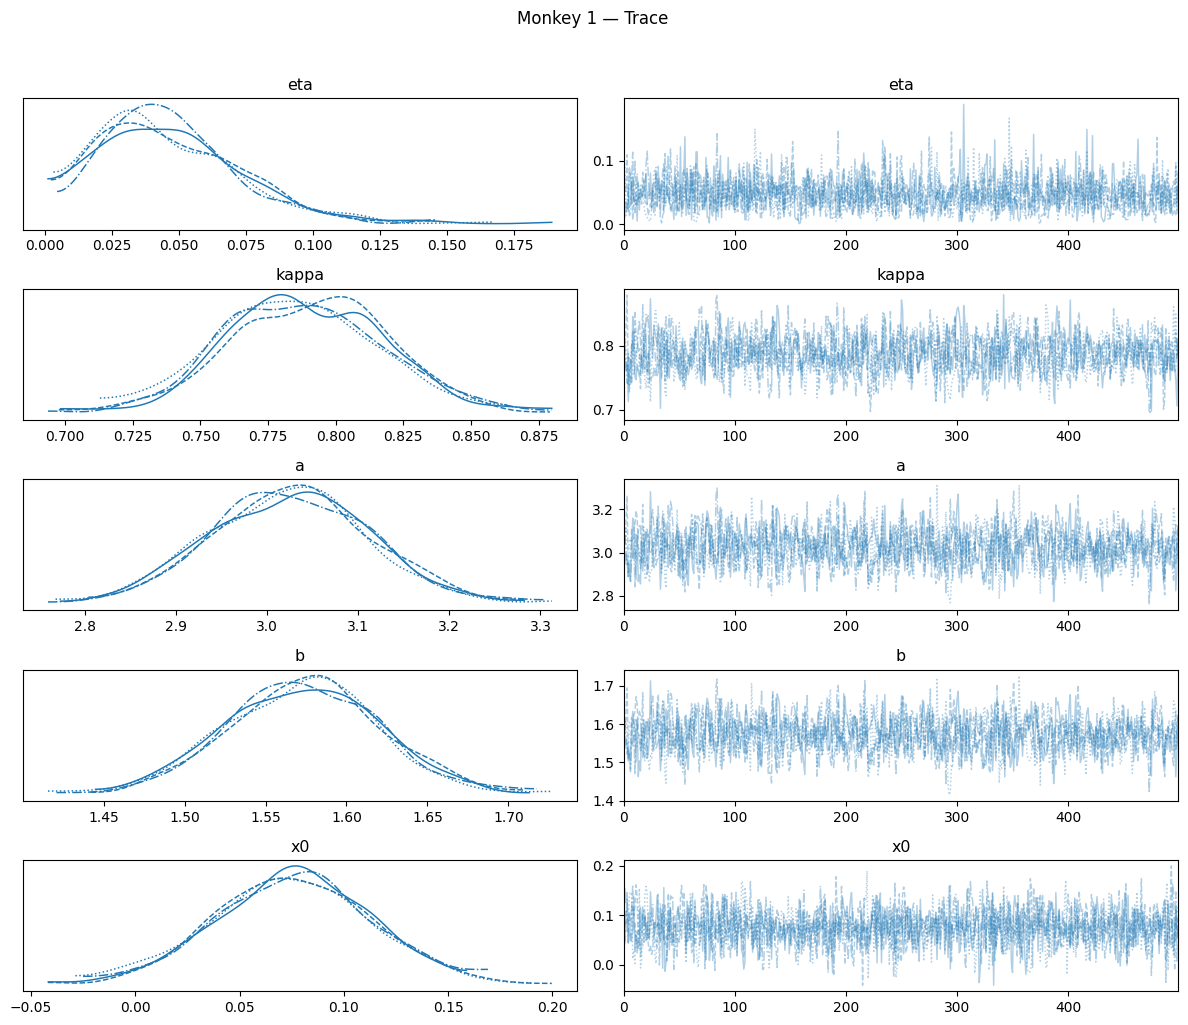

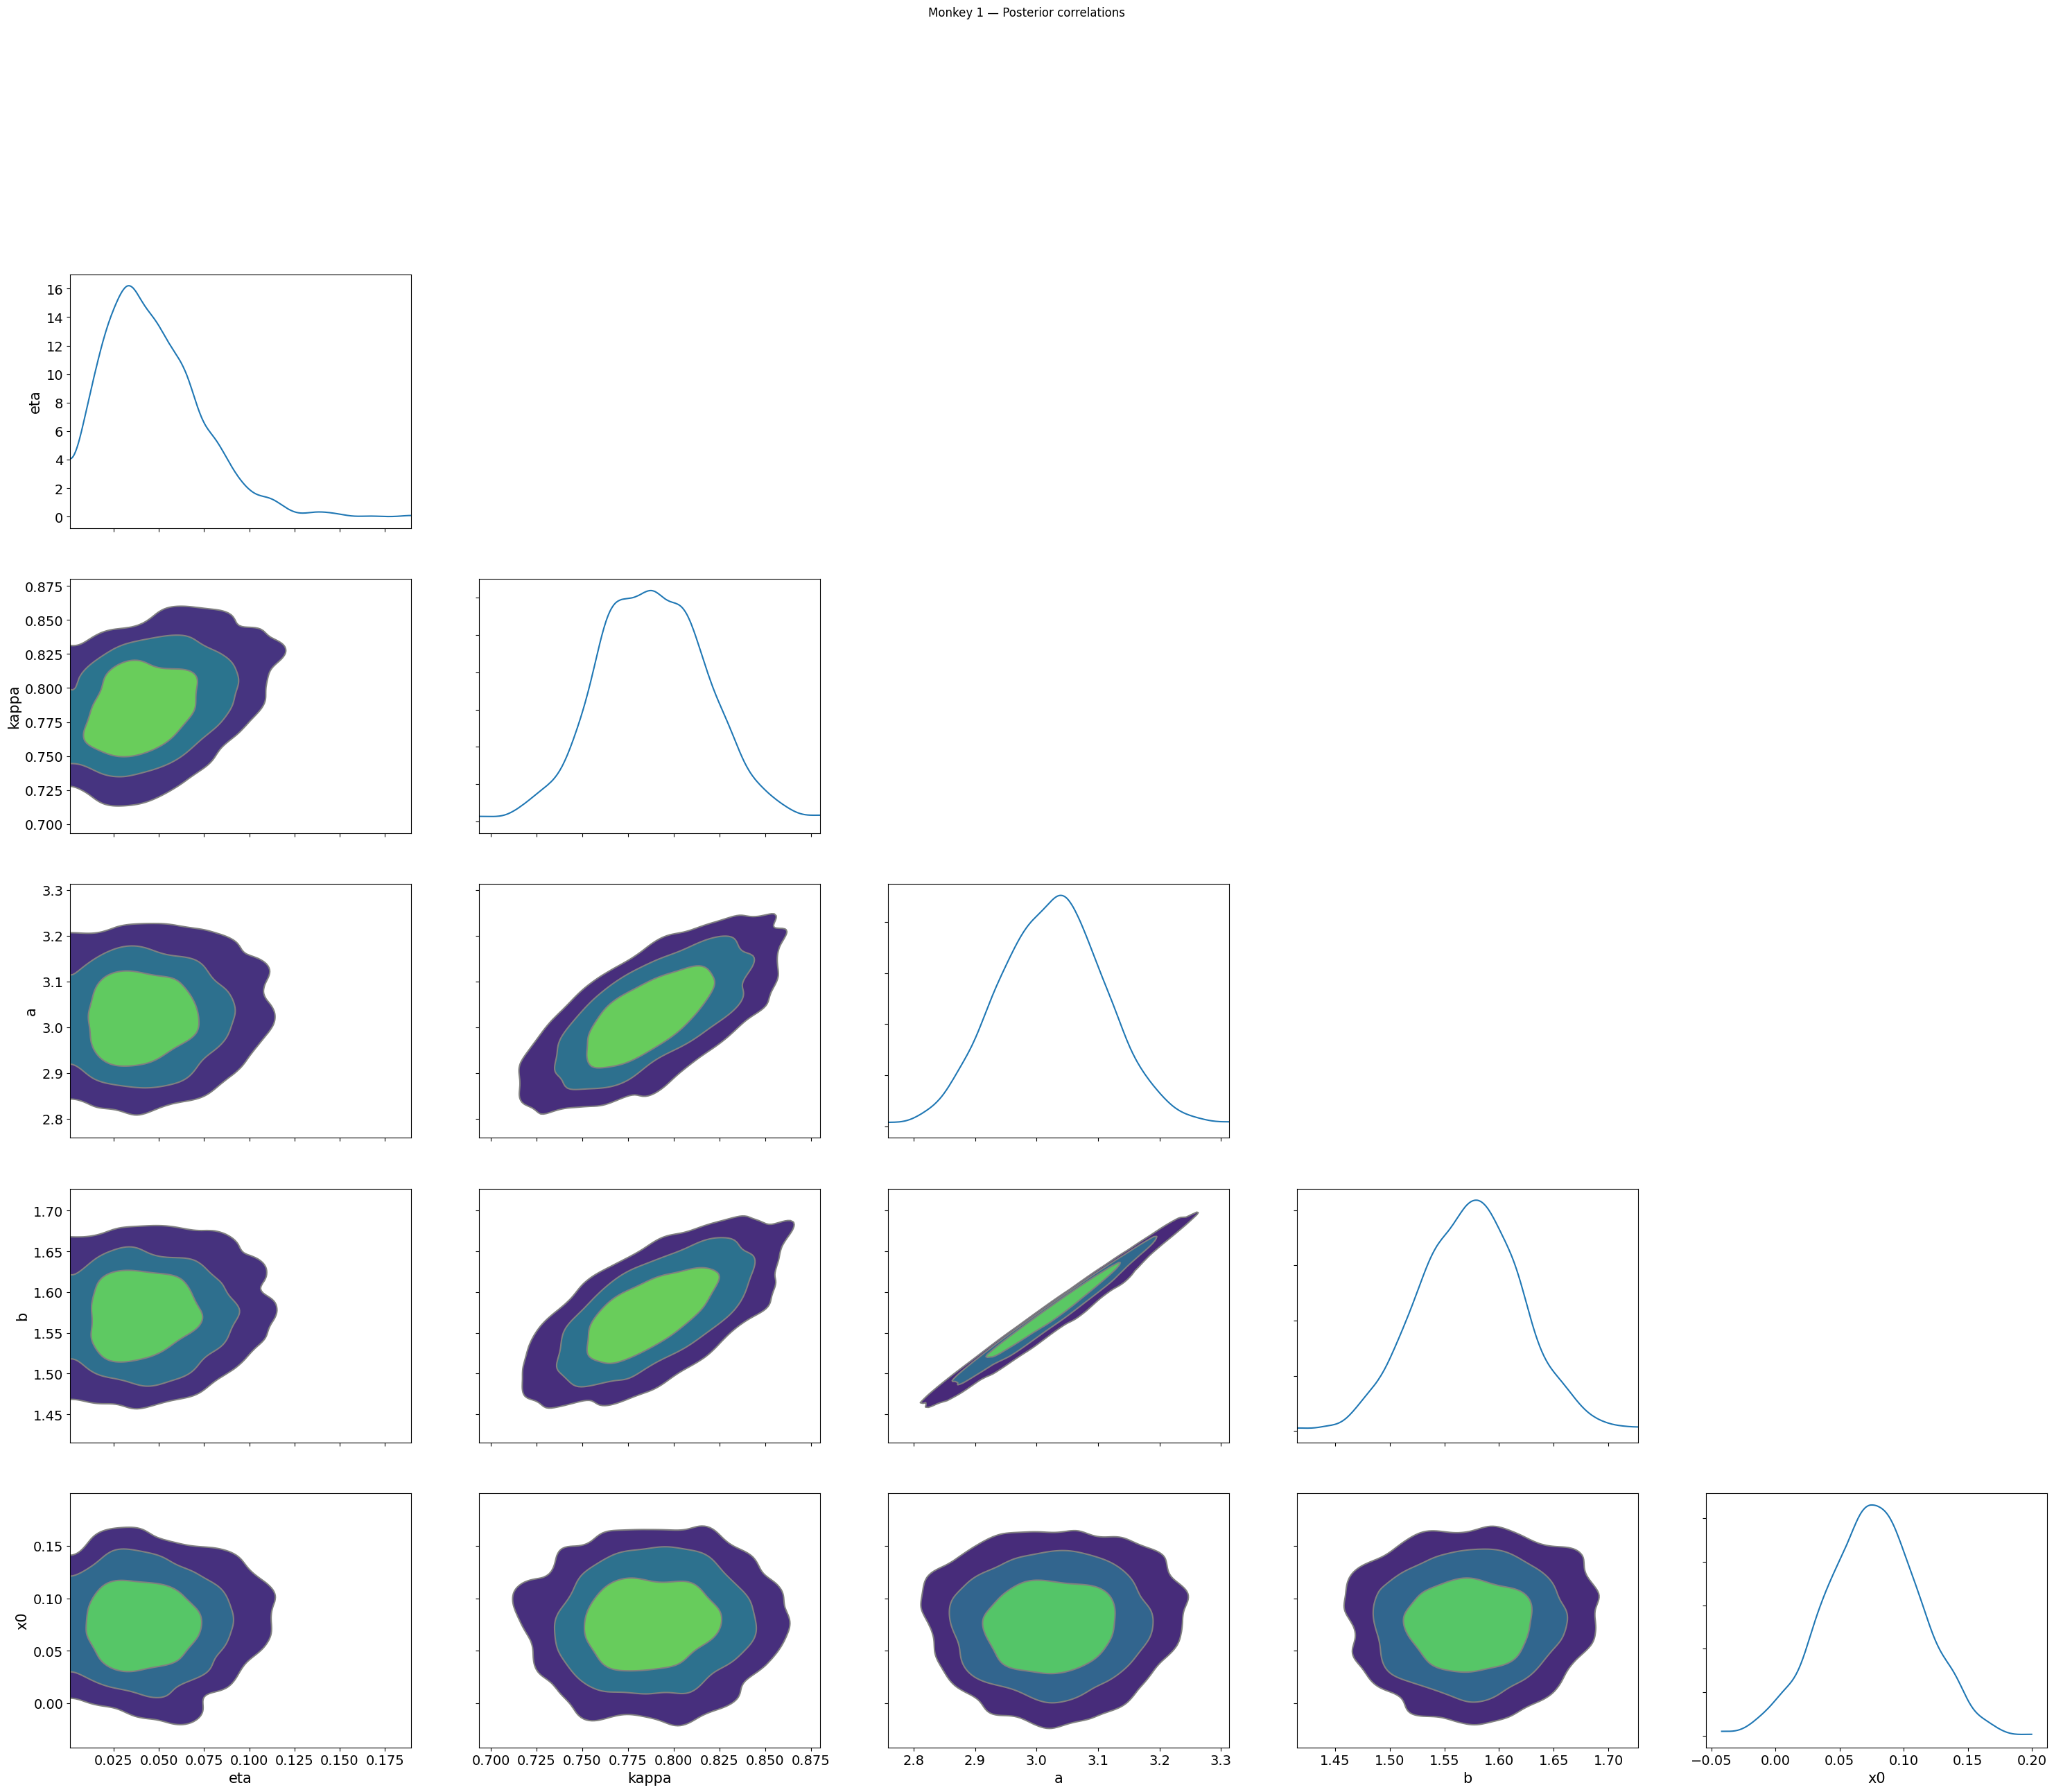

In [31]:
print("=== Monkey 1 Diagnostics ===")
print(az.summary(trace_1, var_names=params))

az.plot_trace(trace_1, var_names=params)
plt.suptitle("Monkey 1 — Trace", y=1.02)
plt.tight_layout()
plt.show()

az.plot_pair(trace_1, var_names=params, kind='kde', marginals=True)
plt.suptitle("Monkey 1 — Posterior correlations", y=1.02)
plt.show()

---
# Monkey 2

In [25]:
data_2     = preprocess_monkey_data_fixdur(monk_data_2, max_d)
jax_data_2 = make_jax_arrays(data_2, max_d)

print(f"Monkey 2 | trials: {len(data_2['rt'])}, max RT: {data_2['rt'].max():.4f}")

Monkey 2 | trials: 605, max RT: 1.9330


In [26]:
loglik_2, grad_2 = make_jax_likelihood(jax_data_2, sigma, max_d, TRUNC_NUM)

print("Warming up JIT for Monkey 2...")
t0_ = time.time()
ll_test_2 = loglik_2(0.7, 0.5, 2.0, 0.3, -0.2)
_          = grad_2(0.7, 0.5, 2.0, 0.3, -0.2)
print(f"JIT warm-up: {time.time()-t0_:.1f}s  |  ll={float(ll_test_2):.4f}")

op_2    = LogLikeJAX(loglik_2, grad_2)
model_2 = make_pymc_model(op_2, float(np.max(data_2['rt'])))
print("Model 2 built.", model_2.point_logps())

Warming up JIT for Monkey 2...


JIT warm-up: 6.6s  |  ll=-517.8852


/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Model 2 built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-275.12)}


In [27]:
print(f"Sampling Monkey 2 | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_2:
    t_start = time.perf_counter()
    trace_2 = pm.sample(
        draws=1000, tune=1000, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample_2 = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total: {t_sample_2:.1f}s")

Sampling Monkey 2 | 500 draws, 500 tune, 2 chains
Started: 21:10:57


Running chain 1: 100%|██████████| 2000/2000 [03:25<00:00,  9.72it/s]
We recommend running at least 4 chains for robust computation of convergence diagnostics


Finished: 21:14:25
Total: 208.3s


=== Monkey 2 Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.012  0.008   0.000    0.027      0.000    0.000    1797.0     988.0   
kappa  1.036  0.033   0.978    1.100      0.001    0.001    1116.0    1250.0   
a      3.160  0.089   2.979    3.312      0.003    0.002    1167.0    1384.0   
b      1.535  0.046   1.454    1.629      0.001    0.001    1214.0    1321.0   
x0     0.067  0.035   0.002    0.131      0.001    0.001    2218.0    1532.0   

       r_hat  
eta      1.0  
kappa    1.0  
a        1.0  
b        1.0  
x0       1.0  


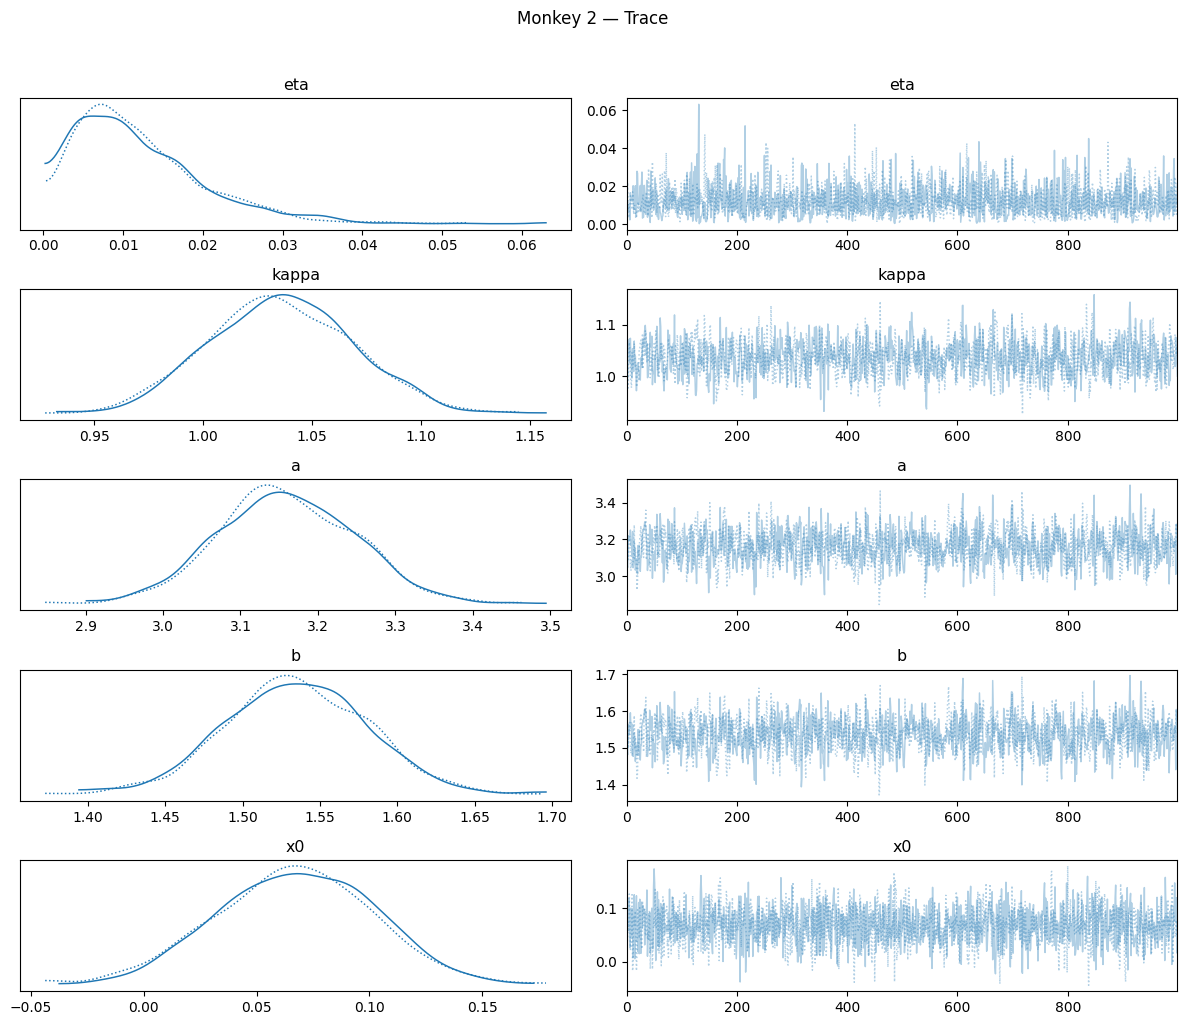

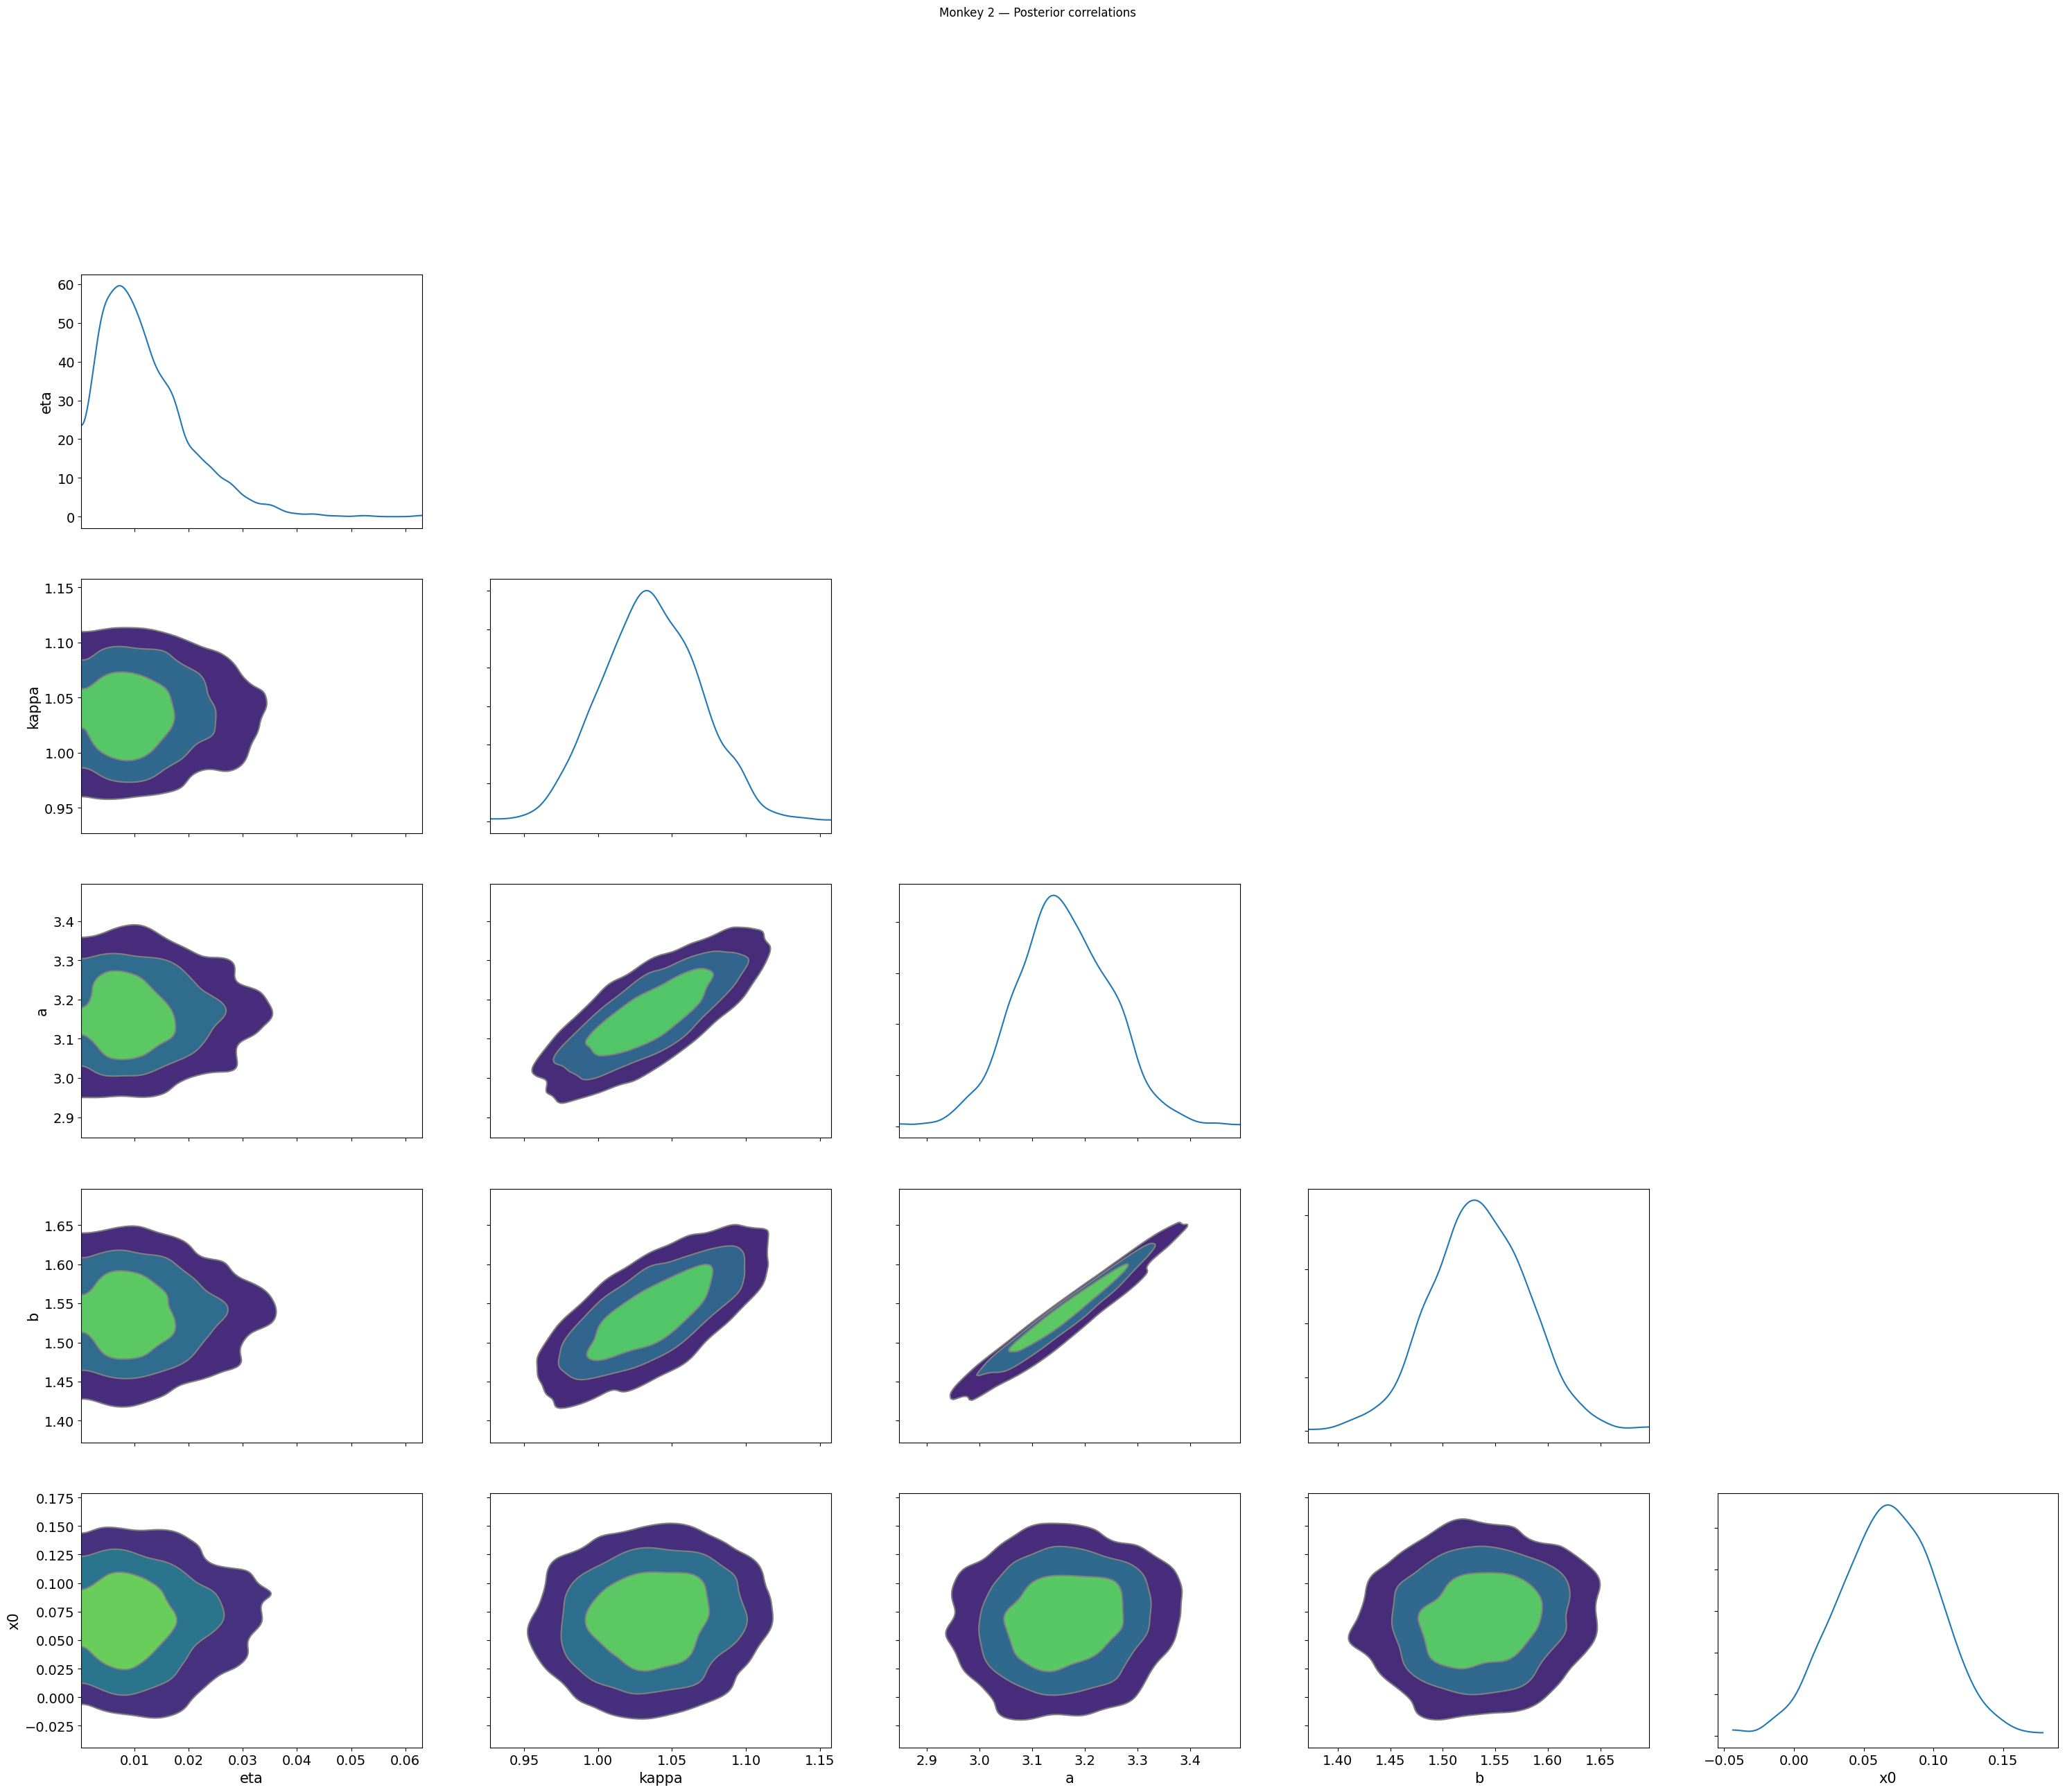

In [30]:
print("=== Monkey 2 Diagnostics ===")
print(az.summary(trace_2, var_names=params))

az.plot_trace(trace_2, var_names=params)
plt.suptitle("Monkey 2 — Trace", y=1.02)
plt.tight_layout()
plt.show()

az.plot_pair(trace_2, var_names=params, kind='kde', marginals=True)
plt.suptitle("Monkey 2 — Posterior correlations", y=1.02)
plt.show()

---
# Monkey 3

In [39]:
data_3     = preprocess_monkey_data_fixdur(monk_data_3, max_d)
jax_data_3 = make_jax_arrays(data_3, max_d)

print(f"Monkey 3 | trials: {len(data_3['rt'])}, max RT: {data_3['rt'].max():.4f}")

Monkey 3 | trials: 606, max RT: 2.0273


In [40]:
loglik_3, grad_3 = make_jax_likelihood(jax_data_3, sigma, max_d, TRUNC_NUM)

print("Warming up JIT for Monkey 3...")
t0_ = time.time()
ll_test_3 = loglik_3(0.7, 0.5, 2.0, 0.3, -0.2)
_          = grad_3(0.7, 0.5, 2.0, 0.3, -0.2)
print(f"JIT warm-up: {time.time()-t0_:.1f}s  |  ll={float(ll_test_3):.4f}")

op_3    = LogLikeJAX(loglik_3, grad_3)
model_3 = make_pymc_model(op_3, float(np.max(data_3['rt'])))
print("Model 3 built.", model_3.point_logps())

Warming up JIT for Monkey 3...
JIT warm-up: 6.3s  |  ll=-590.2409
Model 3 built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-372.44)}


In [41]:
print(f"Sampling Monkey 3 | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_3:
    t_start = time.perf_counter()
    trace_3 = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample_3 = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total: {t_sample_3:.1f}s")

Sampling Monkey 3 | 500 draws, 500 tune, 4 chains
Started: 15:37:13


Compiling.. :   0%|          | 0/1000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1000 [00:10<?, ?it/s]


Running chain 0:   5%|▌         | 50/1000 [00:20<03:15,  4.85it/s]








Running chain 0:  10%|█         | 100/1000 [00:43<05:18,  2.83it/s]


Running chain 0:  15%|█▌        | 150/1000 [00:47<03:17,  4.31it/s]




Running chain 0:  20%|██        | 200/1000 [00:49<02:06,  6.33it/s]


Running chain 0:  25%|██▌       | 250/1000 [00:51<01:26,  8.65it/s]


Running chain 0:  30%|███       | 300/1000 [00:54<01:07, 10.32it/s]


Running chain 0:  35%|███▌      | 350/1000 [00:57<00:52, 12.48it/s]


Running chain 0:  40%|████      | 400/1000 [00:59<00:39, 15.01it/s]


Running chain 0:  45%|████▌     | 450/1000 [01:01<00:31, 17.35it/s]




Running chain 0:  50%|█████     | 500/1000 [01:03<00:28, 17.86it/s]


Running chain 0:  55%|█████▌    | 550/1000 [01:05<00:23, 19.14it/s]


Running chain 0:  60%|██████    | 600/1000 [01:07<00:19, 20.61it/s]


Running chain 0:  65%|██████▌  

Finished: 15:38:38
Total: 85.0s


=== Monkey 3 Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.023  0.015   0.001    0.049      0.000    0.000    1674.0    1084.0   
kappa  0.751  0.027   0.704    0.804      0.001    0.001    1212.0    1238.0   
a      2.352  0.066   2.238    2.479      0.002    0.001    1420.0    1620.0   
b      1.088  0.033   1.028    1.149      0.001    0.001    1429.0    1653.0   
x0     0.053  0.035  -0.011    0.121      0.001    0.001    1875.0    1284.0   

       r_hat  
eta      1.0  
kappa    1.0  
a        1.0  
b        1.0  
x0       1.0  


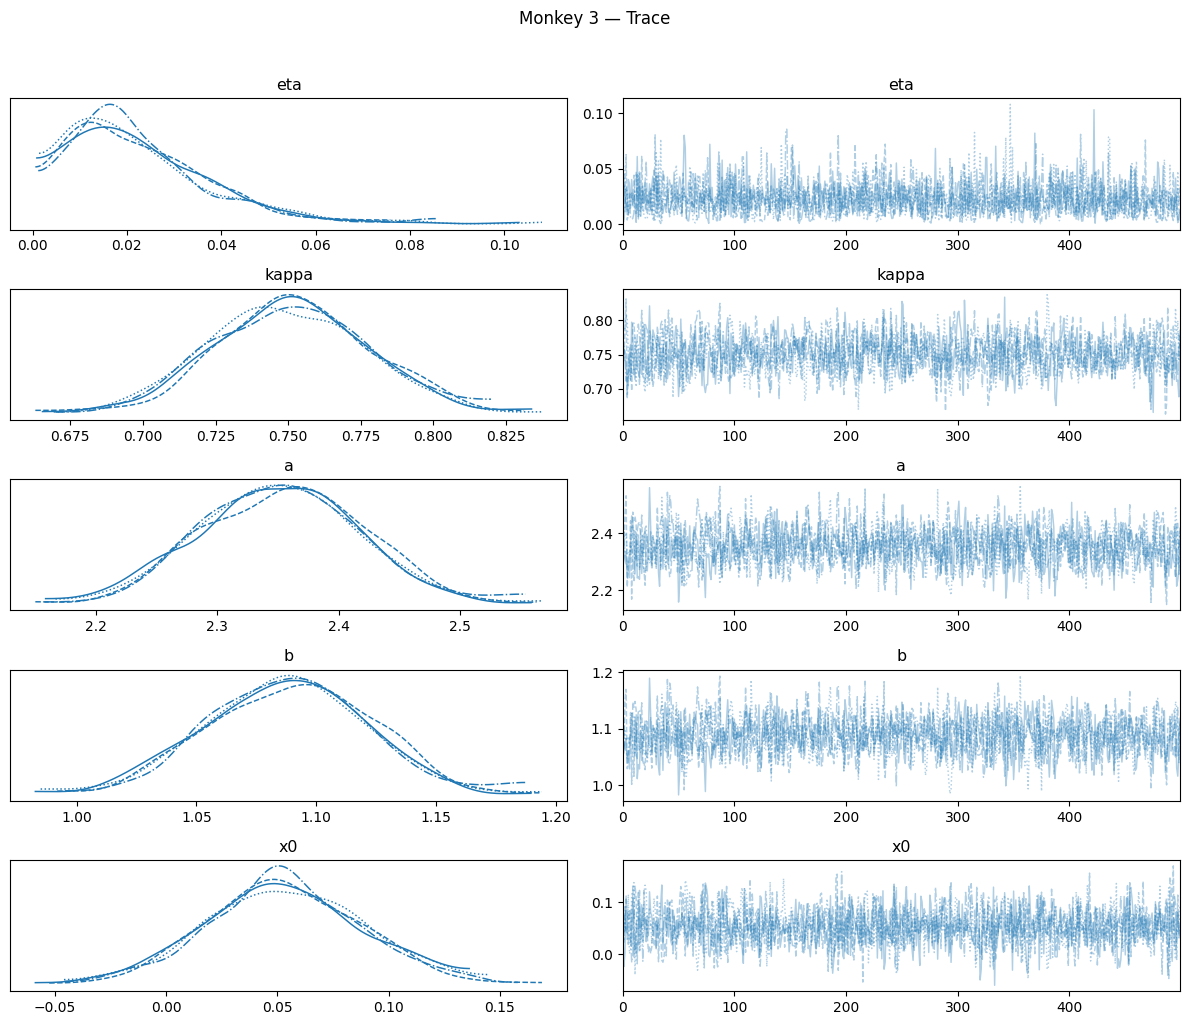

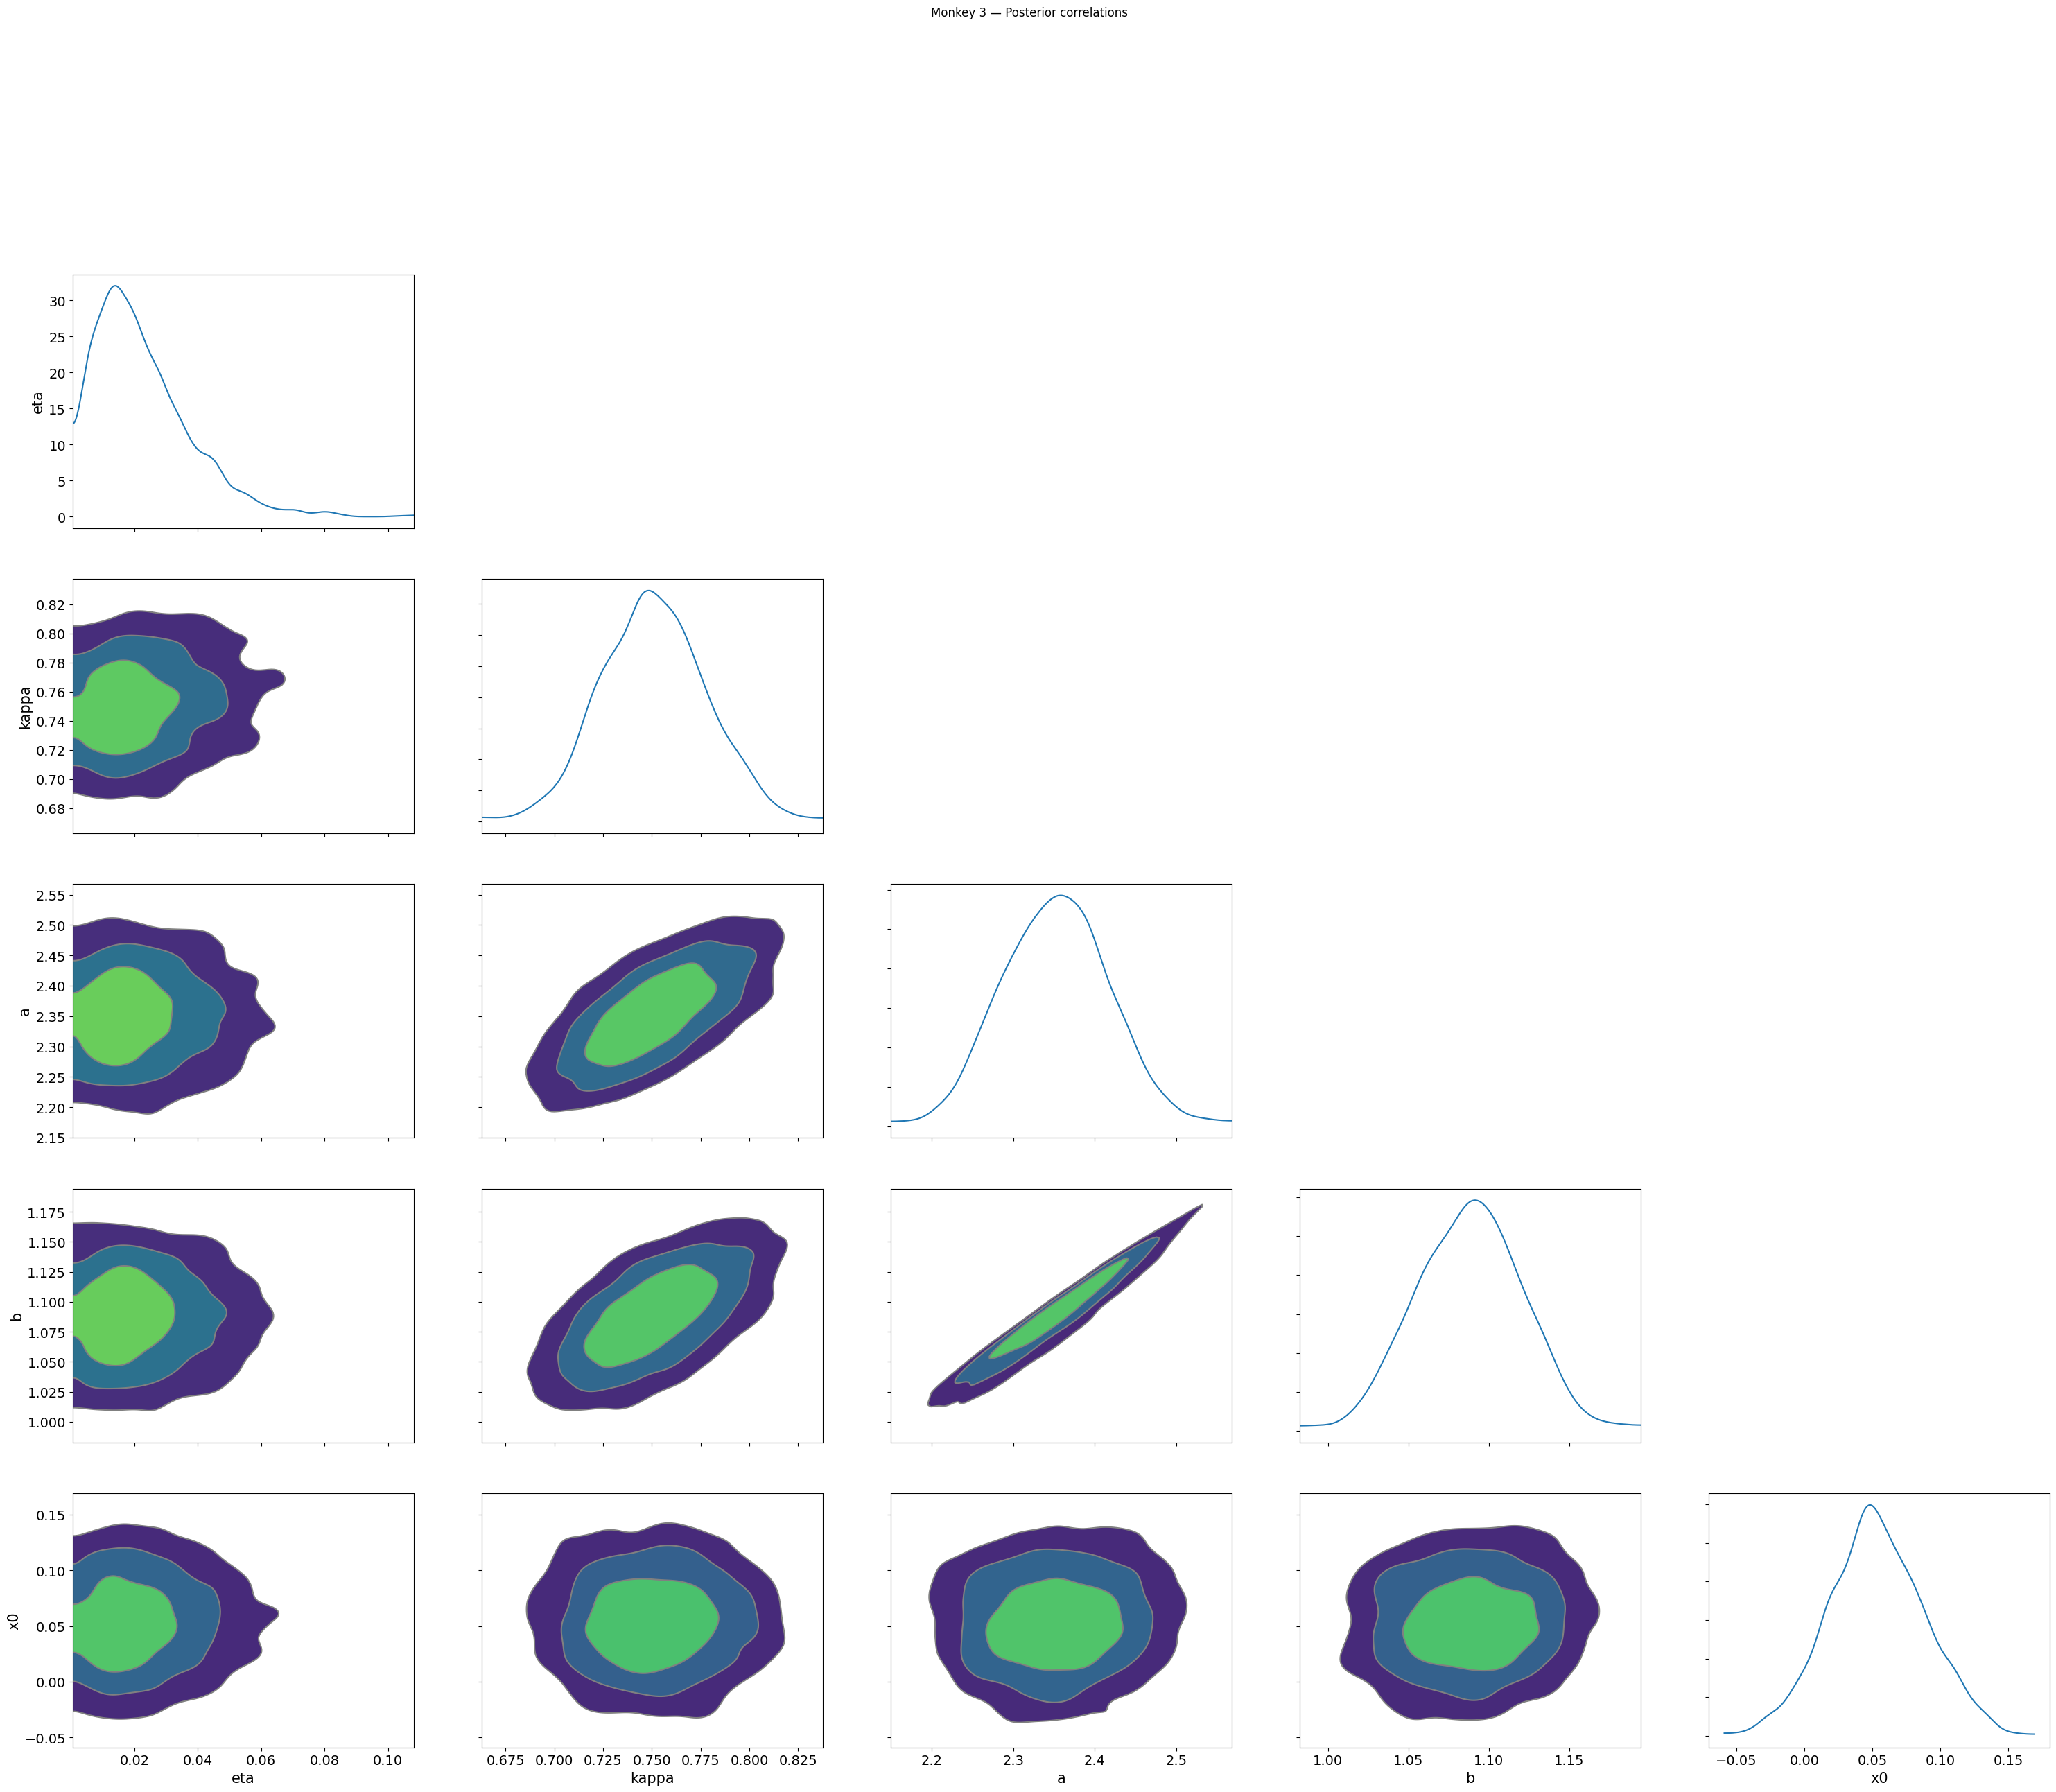

In [42]:
print("=== Monkey 3 Diagnostics ===")
print(az.summary(trace_3, var_names=params))

az.plot_trace(trace_3, var_names=params)
plt.suptitle("Monkey 3 — Trace", y=1.02)
plt.tight_layout()
plt.show()

az.plot_pair(trace_3, var_names=params, kind='kde', marginals=True)
plt.suptitle("Monkey 3 — Posterior correlations", y=1.02)
plt.show()

In [ ]:
# save traces
# trace_1.to_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk1_newdur.nc") 
# trace_2.to_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk2_newdur.nc")
# trace_3.to_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk3_newdur.nc")

'/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk3_newdur.nc'

In [16]:
trace_1_res = az.from_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk1.nc")
trace_2_res = az.from_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk2.nc")
trace_3_res = az.from_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk3.nc")

---
# Posterior Predictive

In [31]:
from efficient_fpt.addm import _build_mu_data_padded
from efficient_fpt.addm_simulator_cy import simulate_addm_batch_cy
from scipy.stats import gaussian_kde


def plot_ppc_by_diff(trace, data, monkey_label,
                     n_ppc_draws=100, ci_lo=2.5, ci_hi=97.5,
                     plot_kind='hist_pooled', seed=2024,
                     n_hist_bins=31,
                     dt=1e-4, max_t=10.0, sigma=1.0, max_d=4):
    """
    Posterior predictive check stratified by (lVal - rVal) difference.

    plot_kind options
    -----------------
    'hist_pooled' : pool simulated signed RTs across ALL posterior draws into a
                    single histogram per bin and overlay the empirical histogram.
                    No per-draw KDE / credible band is computed.
    'hist'        : empirical histogram + per-draw KDE median & credible band.
    'kde'         : empirical KDE + per-draw KDE median & credible band.
    """
    r1       = data['r1']
    r2       = data['r2']
    sacc     = data['sacc']
    length_d = data['length_data']
    flag_d   = data['flag_data']
    emp_rt   = data['rt']
    emp_ch   = data['choice']

    # Flatten posterior chains x draws
    post    = trace.posterior
    eta_s   = post['eta'].values.reshape(-1)
    kappa_s = post['kappa'].values.reshape(-1)
    a_s     = post['a'].values.reshape(-1)
    b_s     = post['b'].values.reshape(-1)
    # b_s = 0.0
    x0_s    = post['x0'].values.reshape(-1)

    rng_pick = np.random.default_rng(seed)
    n_post   = eta_s.size
    draw_idx = rng_pick.choice(n_post, size=min(n_ppc_draws, n_post), replace=False)
    print(f"{monkey_label}: using {len(draw_idx)} posterior draws from {n_post} total.")

    # Difference bins
    diffs        = (r1 - r2).astype(int)
    unique_diffs = np.sort(np.unique(diffs))
    print("  Unique lVal-rVal differences:", unique_diffs.tolist())

    # Empirical signed RTs and x-grids per bin
    emp_signed_by_bin = {}
    x_grids           = {}
    for d in unique_diffs:
        mask = diffs == d
        ok   = mask & (emp_rt > 0)
        es   = emp_rt[ok] * emp_ch[ok]
        emp_signed_by_bin[int(d)] = es
        lim = float(np.abs(es).max() * 1.2) if len(es) else 1.0
        x_grids[int(d)] = np.linspace(-lim, lim, 300)

    pooled_mode = (plot_kind == 'hist_pooled')

    # Storage:
    #   pooled_mode        -> one flat array of simulated signed RTs per bin
    #   'hist' / 'kde'     -> list of per-draw KDE curves per bin
    sim_pooled_by_bin = {int(d): [] for d in unique_diffs}
    kde_curves_by_bin = {int(d): [] for d in unique_diffs}
    rng_sim = np.random.default_rng(seed + 1)

    for k, idx in enumerate(draw_idx):
        eta_k   = float(eta_s[idx])
        kappa_k = float(kappa_s[idx])
        a_k     = float(a_s[idx])
        b_k     = float(b_s[idx])
        # b_k = 0.0
        x0_k    = float(x0_s[idx])

        mu1_k = kappa_k * (r1 - eta_k * r2)
        mu2_k = kappa_k * (eta_k * r1 - r2)
        mu_data_k = _build_mu_data_padded(
            mu1_k.astype(np.float64), mu2_k.astype(np.float64),
            length_d, flag_d, max_d,
        )
        budget_time_k  = min(a_k / b_k, max_t) if b_k > 0 else max_t
        budget_steps_k = int(budget_time_k / dt) + 1

        for d in unique_diffs:
            mask  = diffs == d
            n_bin = int(mask.sum())
            if n_bin == 0:
                continue
            gnoise = np.ascontiguousarray(
                rng_sim.standard_normal((n_bin, budget_steps_k), dtype=np.float64)
            )
            sim_rt_k, sim_ch_k = simulate_addm_batch_cy(
                np.ascontiguousarray(mu_data_k[mask]),
                np.ascontiguousarray(sacc[mask]),
                np.ascontiguousarray(length_d[mask]),
                sigma, a_k, b_k, x0_k, dt, budget_time_k, gnoise,
            )
            sim_rt_k = np.array(sim_rt_k)
            sim_ch_k = np.array(sim_ch_k)
            ok = sim_rt_k > 0
            sim_signed = sim_rt_k[ok] * sim_ch_k[ok]

            if pooled_mode:
                sim_pooled_by_bin[int(d)].append(sim_signed)
            else:
                xg = x_grids[int(d)]
                kde_vals = gaussian_kde(sim_signed)(xg) if len(sim_signed) > 2 else np.zeros_like(xg)
                kde_curves_by_bin[int(d)].append(kde_vals)

        if (k + 1) % 20 == 0 or k + 1 == len(draw_idx):
            print(f"  draw {k+1}/{len(draw_idx)}")

    # ---- plot ----
    n_bins = len(unique_diffs)
    n_cols = 3
    n_rows = int(np.ceil(n_bins / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    ci_width = int(ci_hi - ci_lo)

    for ax, d in zip(axes, unique_diffs):
        emp_signed = emp_signed_by_bin[int(d)]
        xg         = x_grids[int(d)]

        if plot_kind == 'hist_pooled':
            sim_pooled = (np.concatenate(sim_pooled_by_bin[int(d)])
                          if len(sim_pooled_by_bin[int(d)]) else np.array([]))
            bins = np.linspace(xg[0], xg[-1], n_hist_bins)
            ax.hist(emp_signed, bins=bins, density=True, alpha=0.5,
                    color='red', label=f'Monkey (n={len(emp_signed)})')
            if len(sim_pooled):
                ax.hist(sim_pooled, bins=bins, density=True, alpha=0.5,
                        color='blue',
                        label=f'Simulated pooled (n={len(sim_pooled)}, '
                              f'{len(draw_idx)} draws)')
        elif plot_kind == 'hist':
            curves = np.array(kde_curves_by_bin[int(d)])
            bins = np.linspace(xg[0], xg[-1], n_hist_bins)
            ax.hist(emp_signed, bins=bins, density=True, alpha=0.5,
                    color='red', label=f'Monkey (n={len(emp_signed)})')
            if len(curves):
                med = np.median(curves, axis=0)
                lo  = np.percentile(curves, ci_lo, axis=0)
                hi  = np.percentile(curves, ci_hi, axis=0)
                ax.plot(xg, med, color='blue', lw=2, label='Simulated median')
                ax.fill_between(xg, lo, hi, color='blue', alpha=0.25,
                                label=f'{ci_width}% CI')
        else:  # kde
            curves = np.array(kde_curves_by_bin[int(d)])
            if len(emp_signed) > 1:
                emp_kde_vals = gaussian_kde(emp_signed)(xg)
                ax.plot(xg, emp_kde_vals, color='red', lw=2,
                        label=f'Monkey (n={len(emp_signed)})')
                ax.fill_between(xg, emp_kde_vals, color='red', alpha=0.15)
            if len(curves):
                med = np.median(curves, axis=0)
                lo  = np.percentile(curves, ci_lo, axis=0)
                hi  = np.percentile(curves, ci_hi, axis=0)
                ax.plot(xg, med, color='blue', lw=2,
                        label=f'Simulated median ({len(curves)} draws)')
                ax.fill_between(xg, lo, hi, color='blue', alpha=0.25,
                                label=f'{ci_width}% CI')

        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        mask = diffs == d
        ax.set_title(f'lVal-rVal = {d:+d}  (N = {int(mask.sum())})')
        ax.set_xlabel('Signed RT (s)  (+: left, -: right chosen)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

    for ax in axes[n_bins:]:
        ax.axis('off')

    plt.suptitle(
        f'Posterior predictive by value difference ({monkey_label})\n',
        y=1.01, fontsize=13,
    )
    plt.tight_layout()
    plt.show()


Monkey 1: using 100 posterior draws from 2000 total.
  Unique lVal-rVal differences: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
  draw 20/100
  draw 40/100
  draw 60/100
  draw 80/100
  draw 100/100


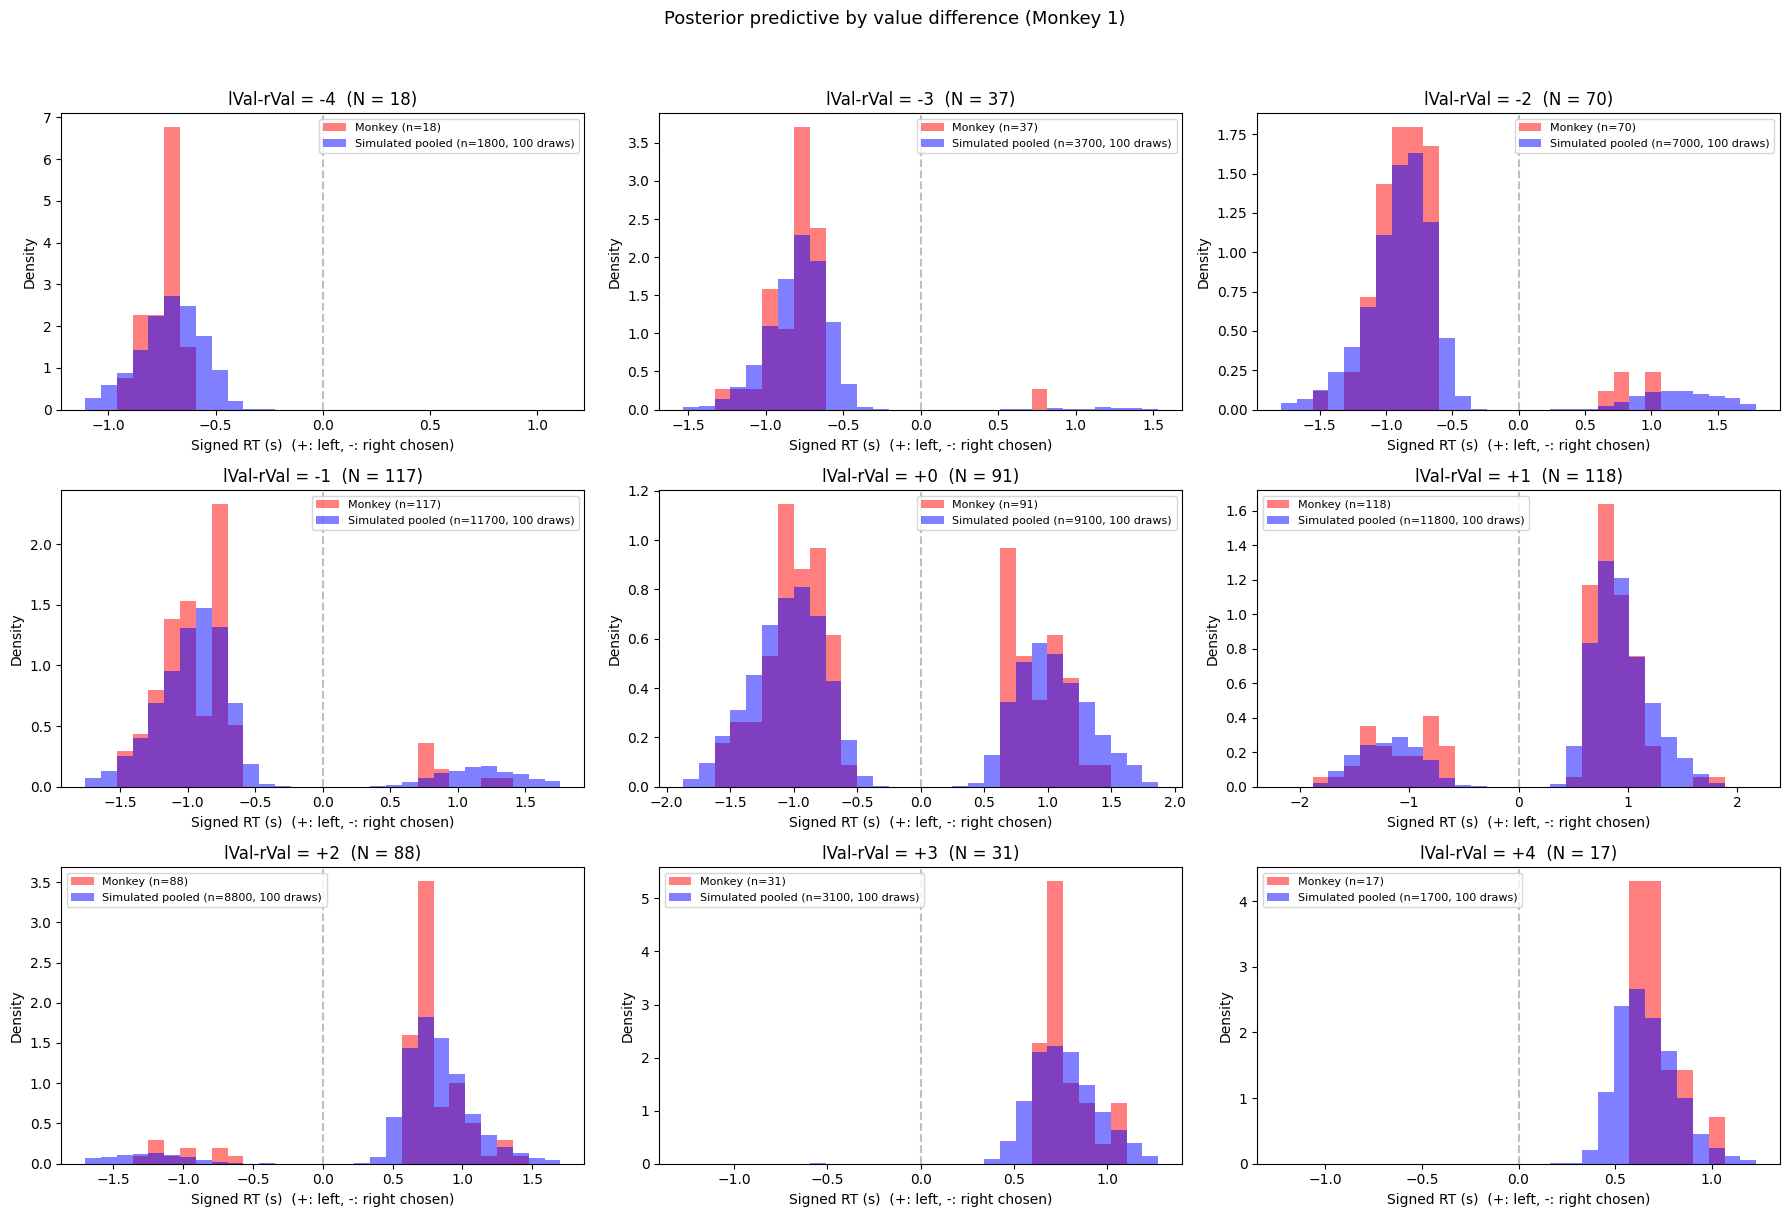

In [33]:
plot_ppc_by_diff(trace_1, data_1, 'Monkey 1')


Monkey 1 (with b): using 100 posterior draws from 2000 total.
  Unique lVal-rVal differences: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
  draw 20/100
  draw 40/100
  draw 60/100
  draw 80/100
  draw 100/100


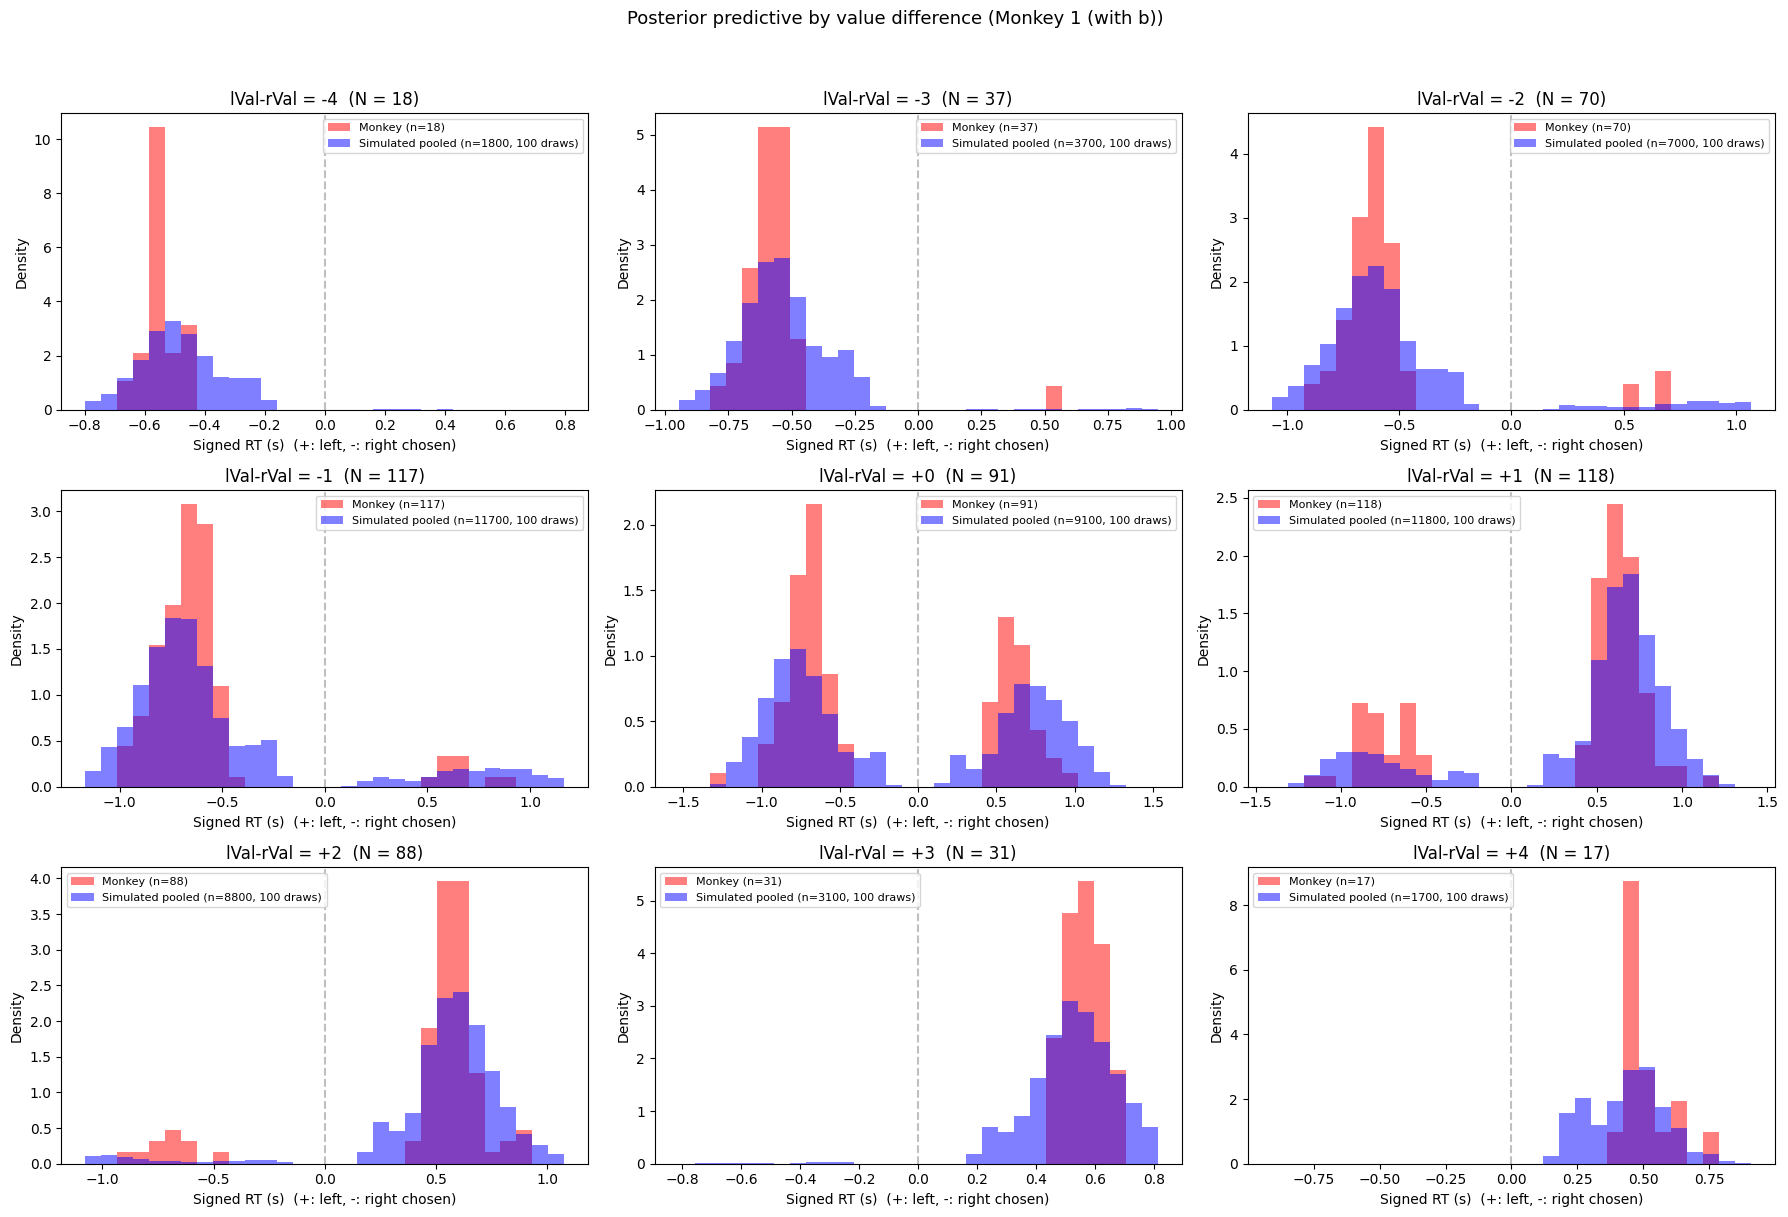

In [57]:
plot_ppc_by_diff(trace_1_res, data_1, 'Monkey 1 (with b)')

Monkey 2: using 100 posterior draws from 2000 total.
  Unique lVal-rVal differences: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
  draw 20/100
  draw 40/100
  draw 60/100
  draw 80/100
  draw 100/100


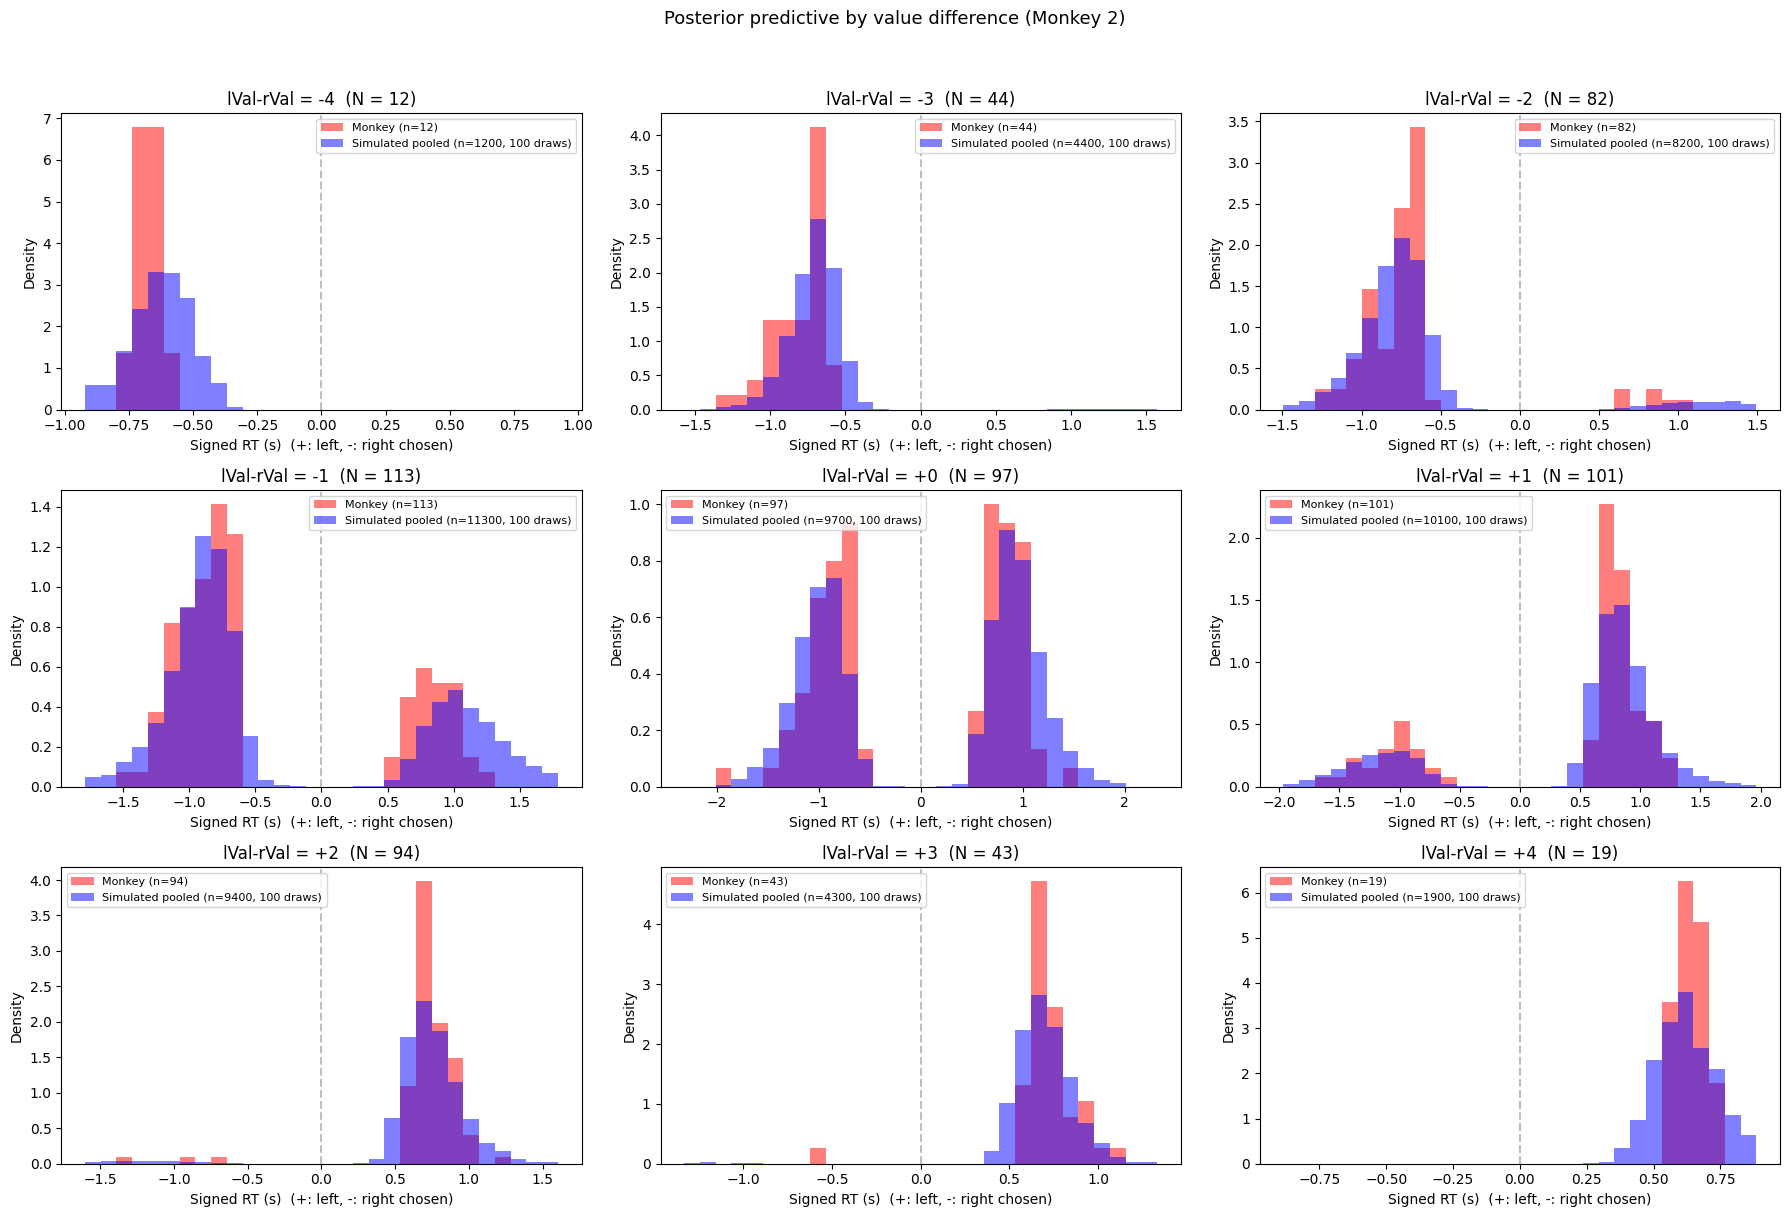

In [32]:
plot_ppc_by_diff(trace_2, data_2, 'Monkey 2')


Monkey 3: using 100 posterior draws from 2000 total.
  Unique lVal-rVal differences: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
  draw 20/100
  draw 40/100
  draw 60/100
  draw 80/100
  draw 100/100


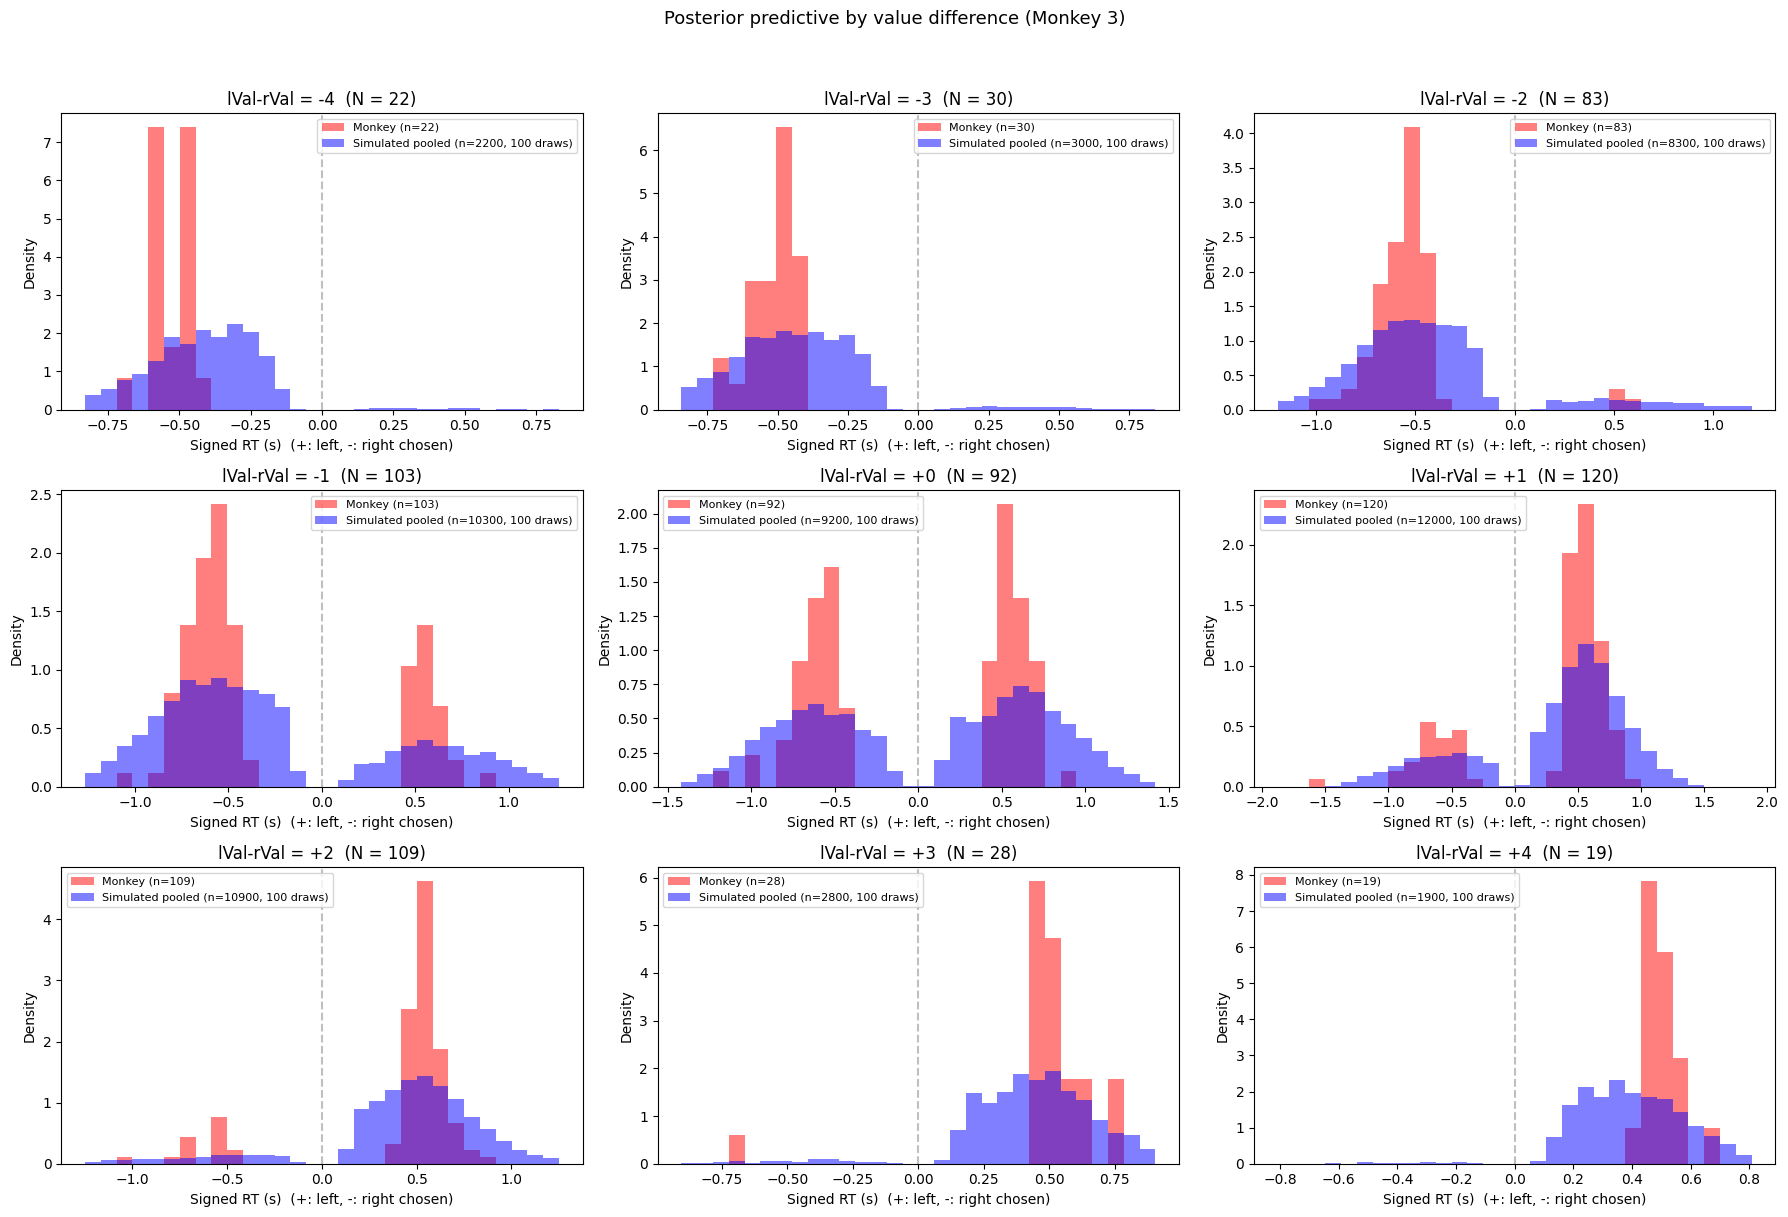

In [59]:
plot_ppc_by_diff(trace_3_res, data_3, 'Monkey 3')


Monkey 3: using 100 posterior draws from 2000 total.
  Unique lVal-rVal differences: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
  draw 20/100
  draw 40/100
  draw 60/100
  draw 80/100
  draw 100/100


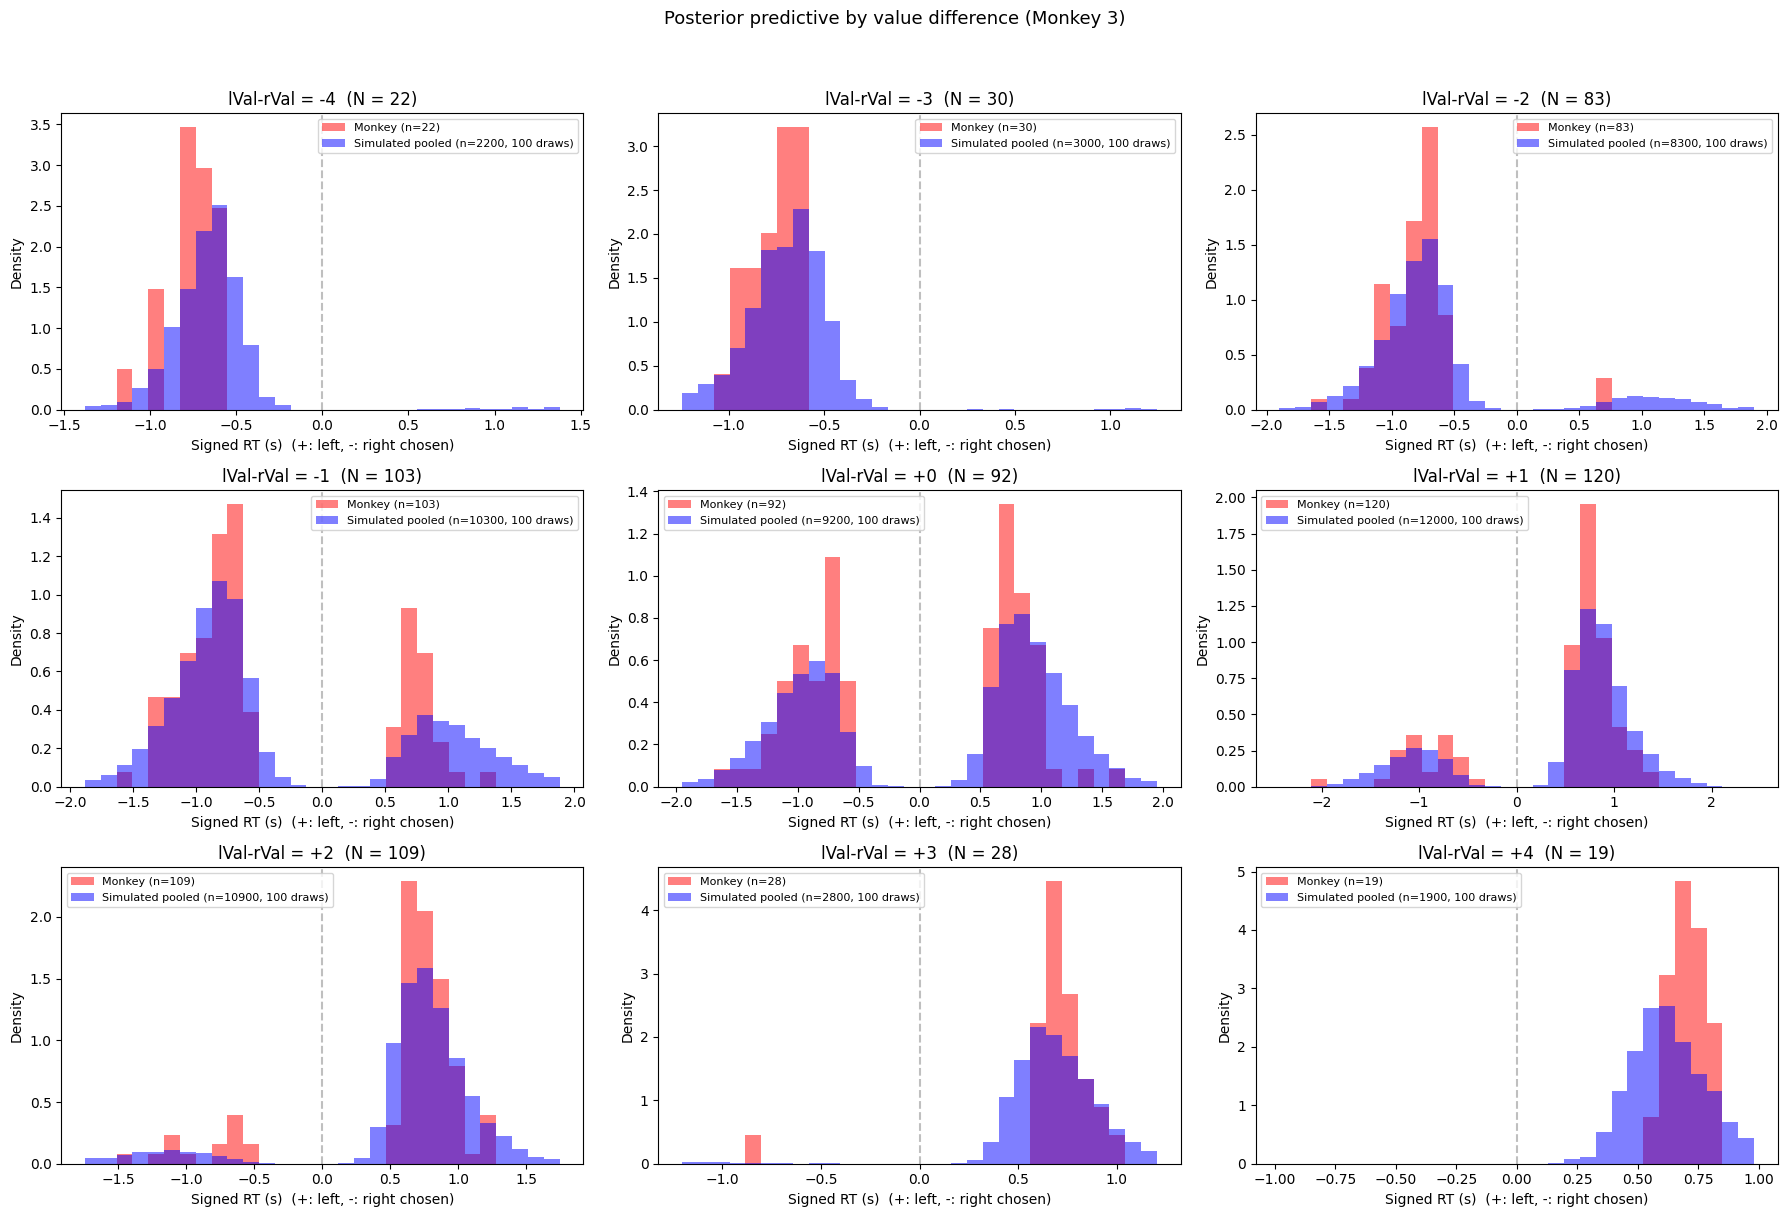

In [43]:
plot_ppc_by_diff(trace_3, data_3, 'Monkey 3')